<a href="https://colab.research.google.com/github/Alice-Ferri/data-intensive-project-2026/blob/main/data-intensive-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Determinare la categoria della malattia della cellula.

Programmazione di data intensive a.a. 2025/2026

Alice Ferri, alice.ferri8@studio.unibo.it

Davide rossi, davide.rossi47@studio.unibo.it

# Parte 1 - Descrizione del contesto del problema

Il dataset di riferimento è [rilevamento di anomalie di cellule del sangue](https://www.kaggle.com/datasets/alitaqishah/blood-cell-anomaly-detection-2025/data) presente in Kaggle.

Il dataset contiene le informazioni di cellule del sangue sane e malate.
Tali dati permettono di suddividere le cellule in 7 categorie, 5 di queste classificate come anomale e 2 come normali.

L'obbiettivo del progetto è sviluppare un classificatore che sia in grando di determinare la categoria della cellula.

### Caricamento librerie

Installiamo nel kernel la libreria per importare il dataset da kagglehub

In [135]:
pip install kagglehub[pandas-datasets]

zsh:1: no matches found: kagglehub[pandas-datasets]
Note: you may need to restart the kernel to use updated packages.


Importiamo le librerie che utilizzeremo

In [136]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter

### Caricamento dei dati e preprocessing

Carichiamo il dataset in un pandas dataframe da kagglehub

In [137]:
# nome del file del dataset
file_path = "blood_cell_anomaly_detection.csv"

data_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "alitaqishah/blood-cell-anomaly-detection-2025",
  file_path
)

data_raw.tail()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
5875,CELL_003773,Platelet,0,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,1.54,1.0,0.681,24,20,219,138,176,0.618,Adult,F,8894,5.37,12.7,37.3,310767,81.4,34.2,CytoData,May_Grunwald_Giemsa,Olympus_BX51,40,360,0.1178,1.0000,0.8849
5876,CELL_005192,Target_Cell,1,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,1.12,1.0,0.920,205,44,248,152,123,0.412,Adult,M,5499,4.12,17.1,33.2,180228,88.1,34.4,Raabin_WBC,Giemsa,Zeiss_Axio,40,224,0.9034,0.9475,0.5928
5877,CELL_005227,Target_Cell,1,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,1.07,1.0,0.954,198,43,216,128,134,0.454,Elderly,F,9606,5.44,15.9,45.7,293938,86.7,34.0,PBC_Dataset,Giemsa,Olympus_BX51,40,256,0.8493,0.6716,0.6381
5878,CELL_005391,Hypersegmented_Neutrophil,1,Infection,11.98,67.8,0.528,0.309,0.752,0.505,3.46,4.7,0.773,453,87,208,133,195,0.597,Adult,M,8021,5.19,13.8,42.1,298582,96.5,32.9,CytoData,Giemsa,Leica_DM2000,100,256,0.9004,0.6449,0.8801
5879,CELL_000861,Neutrophil,0,Normal_WBC,12.58,51.0,0.619,0.471,0.764,0.341,3.62,3.4,0.785,400,78,185,154,201,0.638,Adult,F,7682,5.71,10.0,37.4,306735,82.7,32.5,CytoData,Giemsa,Olympus_BX51,100,360,0.0854,1.0000,0.9553


Con il metodo info stampiamo le informazioni principali come numero di istanze, data type
per feature, e spazio in memoria

In [138]:
data_raw.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cell_id                                  5880 non-null   str    
 1   cell_type                                5880 non-null   str    
 2   anomaly_label                            5880 non-null   int64  
 3   disease_category                         5880 non-null   str    
 4   cell_diameter_um                         5880 non-null   float64
 5   nucleus_area_pct                         5880 non-null   float64
 6   chromatin_density                        5880 non-null   float64
 7   cytoplasm_ratio                          5880 non-null   float64
 8   circularity                              5880 non-null   float64
 9   eccentricity                             5880 non-null   float64
 10  granularity_score                        5880 non-null   fl

Inoltre si può notare che non sono presenti valori nulli nel dataset.

### Significato delle features
Il dataset contiene 36 features, di seguito sono riportate raggruppate per tipologia:

**Morphology** — diametro, circolarità, eccentricità, lobularità, granularità, area del nucleo, densità della cromatina

**Color** — valori RGB medi, intensità della colorazione

**Clinical CBC** — dati ricavati dagli esami del sangue, come quantità globuli bianchi e rossi, piastrine, emoglobina etc.

**Acquisition** — dati riguardanti l'immagine al microscopio, come il modello, la risoluzione e grado di ingrandimento

**AI Scores** — dati legati al modello CytoDiffusion che risolve la stessa tipologia di problema, come confidenza di anomalia della cellula e di suddivisione del tipo della cellula. Troviamo anche il valore di sicurezza della stima del tipo di cellula di un medico esperto

La variabile che tenteremo di predirre è **disease_category**. Le label possono essere:
- __Normal_WBC__, globuli bianchi normali
- __Normal_RBC__, globuli rossi normali
- __Leukemia__
- __Anemia__
- __Sickle_Cell_Anemia__, anemia falciforme
- __Infection__
- __Artefact__


### Scrematura dei dati

Analizzando il dataset si notano le features _cell_id_ che risulta essere un identificatore del record e _dataset_source_ che contiene il database di riferimento dell'informazione.

Sono variabili non informative per la nostra indagine, si decide così di rimuoverle dal nostro dataset.

Si notano inoltre le features legate all'AI scores _cytodiffusion_anomaly_score_  _cytodiffusion_classification_confidence_, come descritte in precedenze. Queste features sono dei punteggi di confidenza di un modello già esistente allenato sulle stesse cellule di riferimento ed in cui è integrata anche l'analisi delle immagini.
E' presente anche la variabile _labeller_confidence_score_ che rappresenta la stima di confidenza dell' umano esperto.

Si è deciso di rimuovere queste features perchè sono dati che non costituiscono l'input del nostro problema.
Infatti il modello si aspetta di ricevere informazioni legate esclusivamente alla cellula e non dati legati ad altre rilevazioni, risulterebbe influente per l'apprendimento del nostro modello e altererebbero la considerazioni di altre variabili importanti. In un caso reale il modello non avrebbe a disposizione queste informazioni.

Si preserva anche il dataset nella forma originale con le suddette features per utilizzarle nella fase di valutazione dei modelli sviluppati.

In [139]:
ds = data_raw.copy()

ds.drop(columns=['cell_id',
                 'dataset_source',
                 'cytodiffusion_anomaly_score',
                 'cytodiffusion_classification_confidence',
                 'labeller_confidence_score'], inplace=True)

In [140]:
ds.head(10)

,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,staining_protocol,microscope_model,magnification_x,image_resolution_px
0,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,0.800,445,90,215,141,160,0.555,Elderly,F,6352,4.44,11.7,43.4,257383,85.5,31.4,Giemsa,Zeiss_Axio,100,224
1,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,0.737,383,61,189,136,169,0.692,Elderly,M,7709,4.90,13.9,42.2,302274,92.5,35.0,Wright,Zeiss_Axio,100,224
2,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,0.790,418,52,193,150,203,0.593,Adult,M,7451,5.72,16.1,39.2,229996,76.3,33.0,Wright,Leica_DM2000,100,512
3,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,0.937,217,39,227,138,118,0.509,Adult,F,9196,3.42,14.6,54.1,130720,92.3,32.5,Wright,Leica_DM2000,100,512
4,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,0.925,147,50,239,127,113,0.607,Elderly,M,5898,5.36,14.6,36.7,228652,83.9,33.4,Wright,Olympus_BX51,100,224
5,Reactive_Lymphocyte,1,Infection,14.97,57.8,0.730,0.188,0.777,0.351,1.66,1.0,0.848,551,96,189,162,170,0.805,Elderly,F,5005,2.70,14.9,37.2,130816,93.7,32.1,Giemsa,Leica_DM2000,100,224
6,Monocyte,0,Normal_WBC,15.63,63.3,0.503,0.571,0.559,0.312,1.79,1.0,0.696,579,80,196,157,176,0.570,Adult,F,6625,4.01,14.7,39.6,168661,80.9,34.1,Giemsa,Olympus_BX51,60,360
7,Lymphocyte,0,Normal_WBC,9.15,78.3,0.790,0.130,0.820,0.045,0.70,1.0,0.886,277,63,191,160,204,0.789,Pediatric,M,8224,4.04,10.9,38.4,389245,88.5,33.9,Giemsa,Olympus_BX51,60,512
8,Smudge_Cell,1,Artefact,10.10,92.9,0.685,0.050,0.288,0.761,0.15,1.1,0.440,449,78,164,89,218,0.612,Adult,M,7863,5.07,13.8,43.6,217608,80.6,32.0,May_Grunwald_Giemsa,Leica_DM2000,100,512
9,Monocyte,0,Normal_WBC,16.97,64.1,0.454,0.449,0.785,0.575,2.08,1.0,0.723,556,95,204,161,201,0.660,Pediatric,M,5047,4.36,9.9,43.4,248113,66.3,32.8,Wright,Olympus_BX51,100,360


# Parte 2 - Esplorazione dei dati

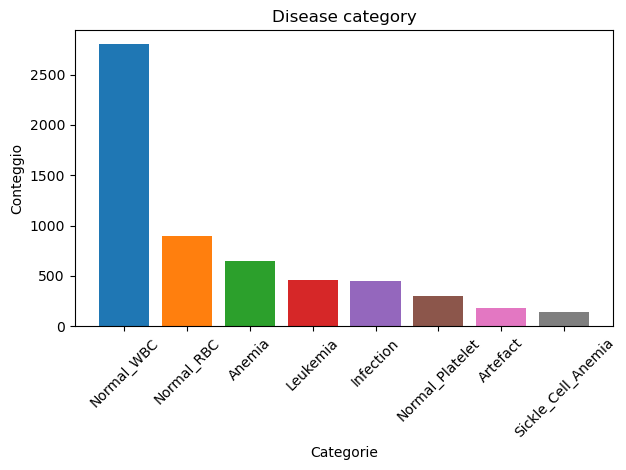

In [141]:
counts = ds['disease_category'].value_counts()
num_categorie = len(counts)

colori = plt.cm.tab10(range(num_categorie)) 

plt.bar(counts.index, counts.values, color=colori)
plt.title('Disease category')
plt.xlabel('Categorie')
plt.ylabel('Conteggio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Osservando il grafico a barre è evidente che la varabile target _disease_category_ risulta essere poco bilanciata, poichè il numero di istanze di tipo Normal_WBC è molto più significativa rispetto alle restanti categorie. Il problema in esame quindi risulta non essere bilanciato, si proverà quindi ad applicare tecniche di bilanciamento come oversampling o undersampling

## Analisi statistiche e valori outlier

Stampiamo le statistiche per le feature del dataset

In [142]:
pd.set_option('display.max_columns', None)
ds.describe()

,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.319728,10.176267,43.537976,0.391394,0.564173,0.769263,0.365458,1.882109,1.769252,0.842866,336.571088,64.068878,212.119218,146.392687,168.664966,0.616362,7043.273980,4.790728,13.547194,41.021956,249792.623469,88.942211,33.495867,76.006803,336.235374
std,0.466411,3.642051,33.419390,0.310006,0.335282,0.158219,0.201501,1.428336,1.229362,0.096033,175.059021,21.290605,19.190629,18.836691,30.619209,0.109240,2481.999916,0.805909,2.025136,5.484636,79472.676228,9.927005,1.480168,25.032178,111.922015
min,0.000000,1.000000,0.000000,0.000000,0.050000,0.100000,0.000000,0.000000,1.000000,0.290000,10.000000,8.000000,123.000000,89.000000,94.000000,0.307000,1000.000000,2.110000,5.400000,20.300000,20000.000000,60.000000,28.000000,40.000000,224.000000
25%,0.000000,7.630000,0.000000,0.000000,0.276000,0.711000,0.214750,0.670000,1.000000,0.784000,189.000000,50.000000,199.000000,132.000000,139.000000,0.526000,5371.750000,4.260000,12.200000,37.300000,194653.250000,82.300000,32.500000,60.000000,224.000000
50%,0.000000,10.055000,54.500000,0.479500,0.452000,0.805000,0.331000,1.320000,1.000000,0.854000,334.000000,64.000000,213.000000,147.000000,176.000000,0.615000,7061.000000,4.800000,13.500000,41.000000,250070.500000,88.900000,33.500000,100.000000,256.000000
75%,1.000000,12.860000,72.300000,0.635000,1.000000,0.879000,0.456000,2.980000,2.300000,0.918000,459.250000,78.000000,226.000000,160.000000,193.000000,0.700000,8727.500000,5.340000,14.900000,44.800000,303863.500000,95.700000,34.500000,100.000000,360.000000
max,1.000000,21.180000,99.000000,1.000000,1.000000,1.000000,0.990000,6.000000,7.200000,1.000000,901.000000,128.000000,255.000000,218.000000,244.000000,1.000000,16855.000000,7.000000,20.000000,60.000000,543084.000000,120.000000,38.000000,100.000000,512.000000


Come si osserva dalla descrizione del dataset, si rilevano media, valore massimo, valore minimo, deviazione standard e percentili di ogni features.
Notiamo già che non sono presenti valori di massimi e minimi fuori da range accettabili per nessuna delle feature

Dopo una prima analisi dei valori sembrerebbe ci sia una discordanza fra
i valori delle feature `cell_area_px` e `image_resolution` in quanto il valore massimo della prima è maggiore del valore massimo della seconda. Queste feature rappresentano per ogni cellula i dati dell'immagine di acquisizione. Si sospetta che la feature cell_area_px possa contenere dei valori outlier

Si selezionano i record dove `cell_area_px > image_resolution` e si nota che questa presunta anomalia è in realtà molto ricorrente nel dataset. Si deduce che la feature image_resolution non indichi il numero totale di pixel nell'immagine bensì la dimensione su un asse dell'immagine e che invece i pixel totali siano `image_resolution^2` . Si verifica che non ci siano cellule con area in px maggiore dell'area totale dell'immagine 

In [143]:
ds.iloc[ds.cell_area_px > ds.image_resolution_px].sort_values(by="cell_area_px")

,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,staining_protocol,microscope_model,magnification_x,image_resolution_px
2615,Target_Cell,1,Anemia,9.11,0.0,0.000,1.000,0.875,0.258,0.72,1.0,0.882,225,40,234,132,131,0.508,Pediatric,M,4137,6.00,10.0,37.3,175938,95.4,31.8,Wright,Leica_DM2000,60,224
5112,Elliptocyte,1,Anemia,7.32,0.0,0.000,1.000,0.503,0.913,0.49,1.0,0.916,225,63,219,127,124,0.455,Adult,F,6304,5.15,18.3,32.3,146335,93.6,32.8,May_Grunwald_Giemsa,Olympus_BX51,100,224
1125,Lymphocyte,0,Normal_WBC,9.02,75.8,0.698,0.274,0.837,0.224,0.81,1.2,0.914,226,54,216,143,190,0.791,Adult,M,7855,4.21,13.6,40.4,261619,97.8,32.7,May_Grunwald_Giemsa,Leica_DM2000,100,224
3591,Lymphocyte,0,Normal_WBC,10.07,85.9,1.000,0.221,0.841,0.186,1.05,1.2,0.939,226,57,182,162,186,0.683,Elderly,M,2303,5.26,14.9,42.8,218575,108.7,33.4,Giemsa,Olympus_BX51,40,224
851,Lymphocyte,0,Normal_WBC,7.54,81.7,0.881,0.159,0.884,0.069,1.36,1.1,0.909,226,62,197,121,204,0.790,Elderly,M,10348,4.02,13.0,40.4,308202,89.8,33.3,Wright,Olympus_BX51,100,224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5269,Blast_Cell,1,Leukemia,15.72,83.0,0.350,0.203,0.857,0.210,0.90,1.0,0.854,851,117,214,132,200,0.645,Elderly,F,9906,4.24,12.0,36.4,278441,89.1,33.5,Giemsa,Olympus_BX51,60,224
3942,Blast_Cell,1,Leukemia,12.92,90.4,0.295,0.082,0.747,0.248,1.18,1.1,0.883,865,105,243,139,197,0.617,Adult,M,7189,3.25,12.9,35.3,286711,94.8,32.4,Giemsa,Zeiss_Axio,40,256
3530,Blast_Cell,1,Leukemia,15.55,77.8,0.341,0.084,0.815,0.282,0.57,1.1,0.811,867,107,209,149,169,0.625,Pediatric,F,6104,4.94,12.3,46.3,197520,83.1,32.0,Giemsa,Zeiss_Axio,100,360
4115,Blast_Cell,1,Leukemia,15.13,87.2,0.298,0.177,0.656,0.249,0.64,1.0,0.931,891,97,123,149,193,0.711,Adult,M,8149,3.71,14.3,42.2,241500,78.3,35.1,Giemsa,Olympus_BX51,60,512


In [144]:
ds.iloc[ds.cell_area_px > ds.image_resolution_px**2]

,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,staining_protocol,microscope_model,magnification_x,image_resolution_px


### Distribuzioni

Si visualizzano le distribuzioni di tutte le variabili continue del dataset, escludendo quelle non legate ai dati della cellula e in cui l'unità di misura è un punteggio attribuito su una scala di valori possibili. 

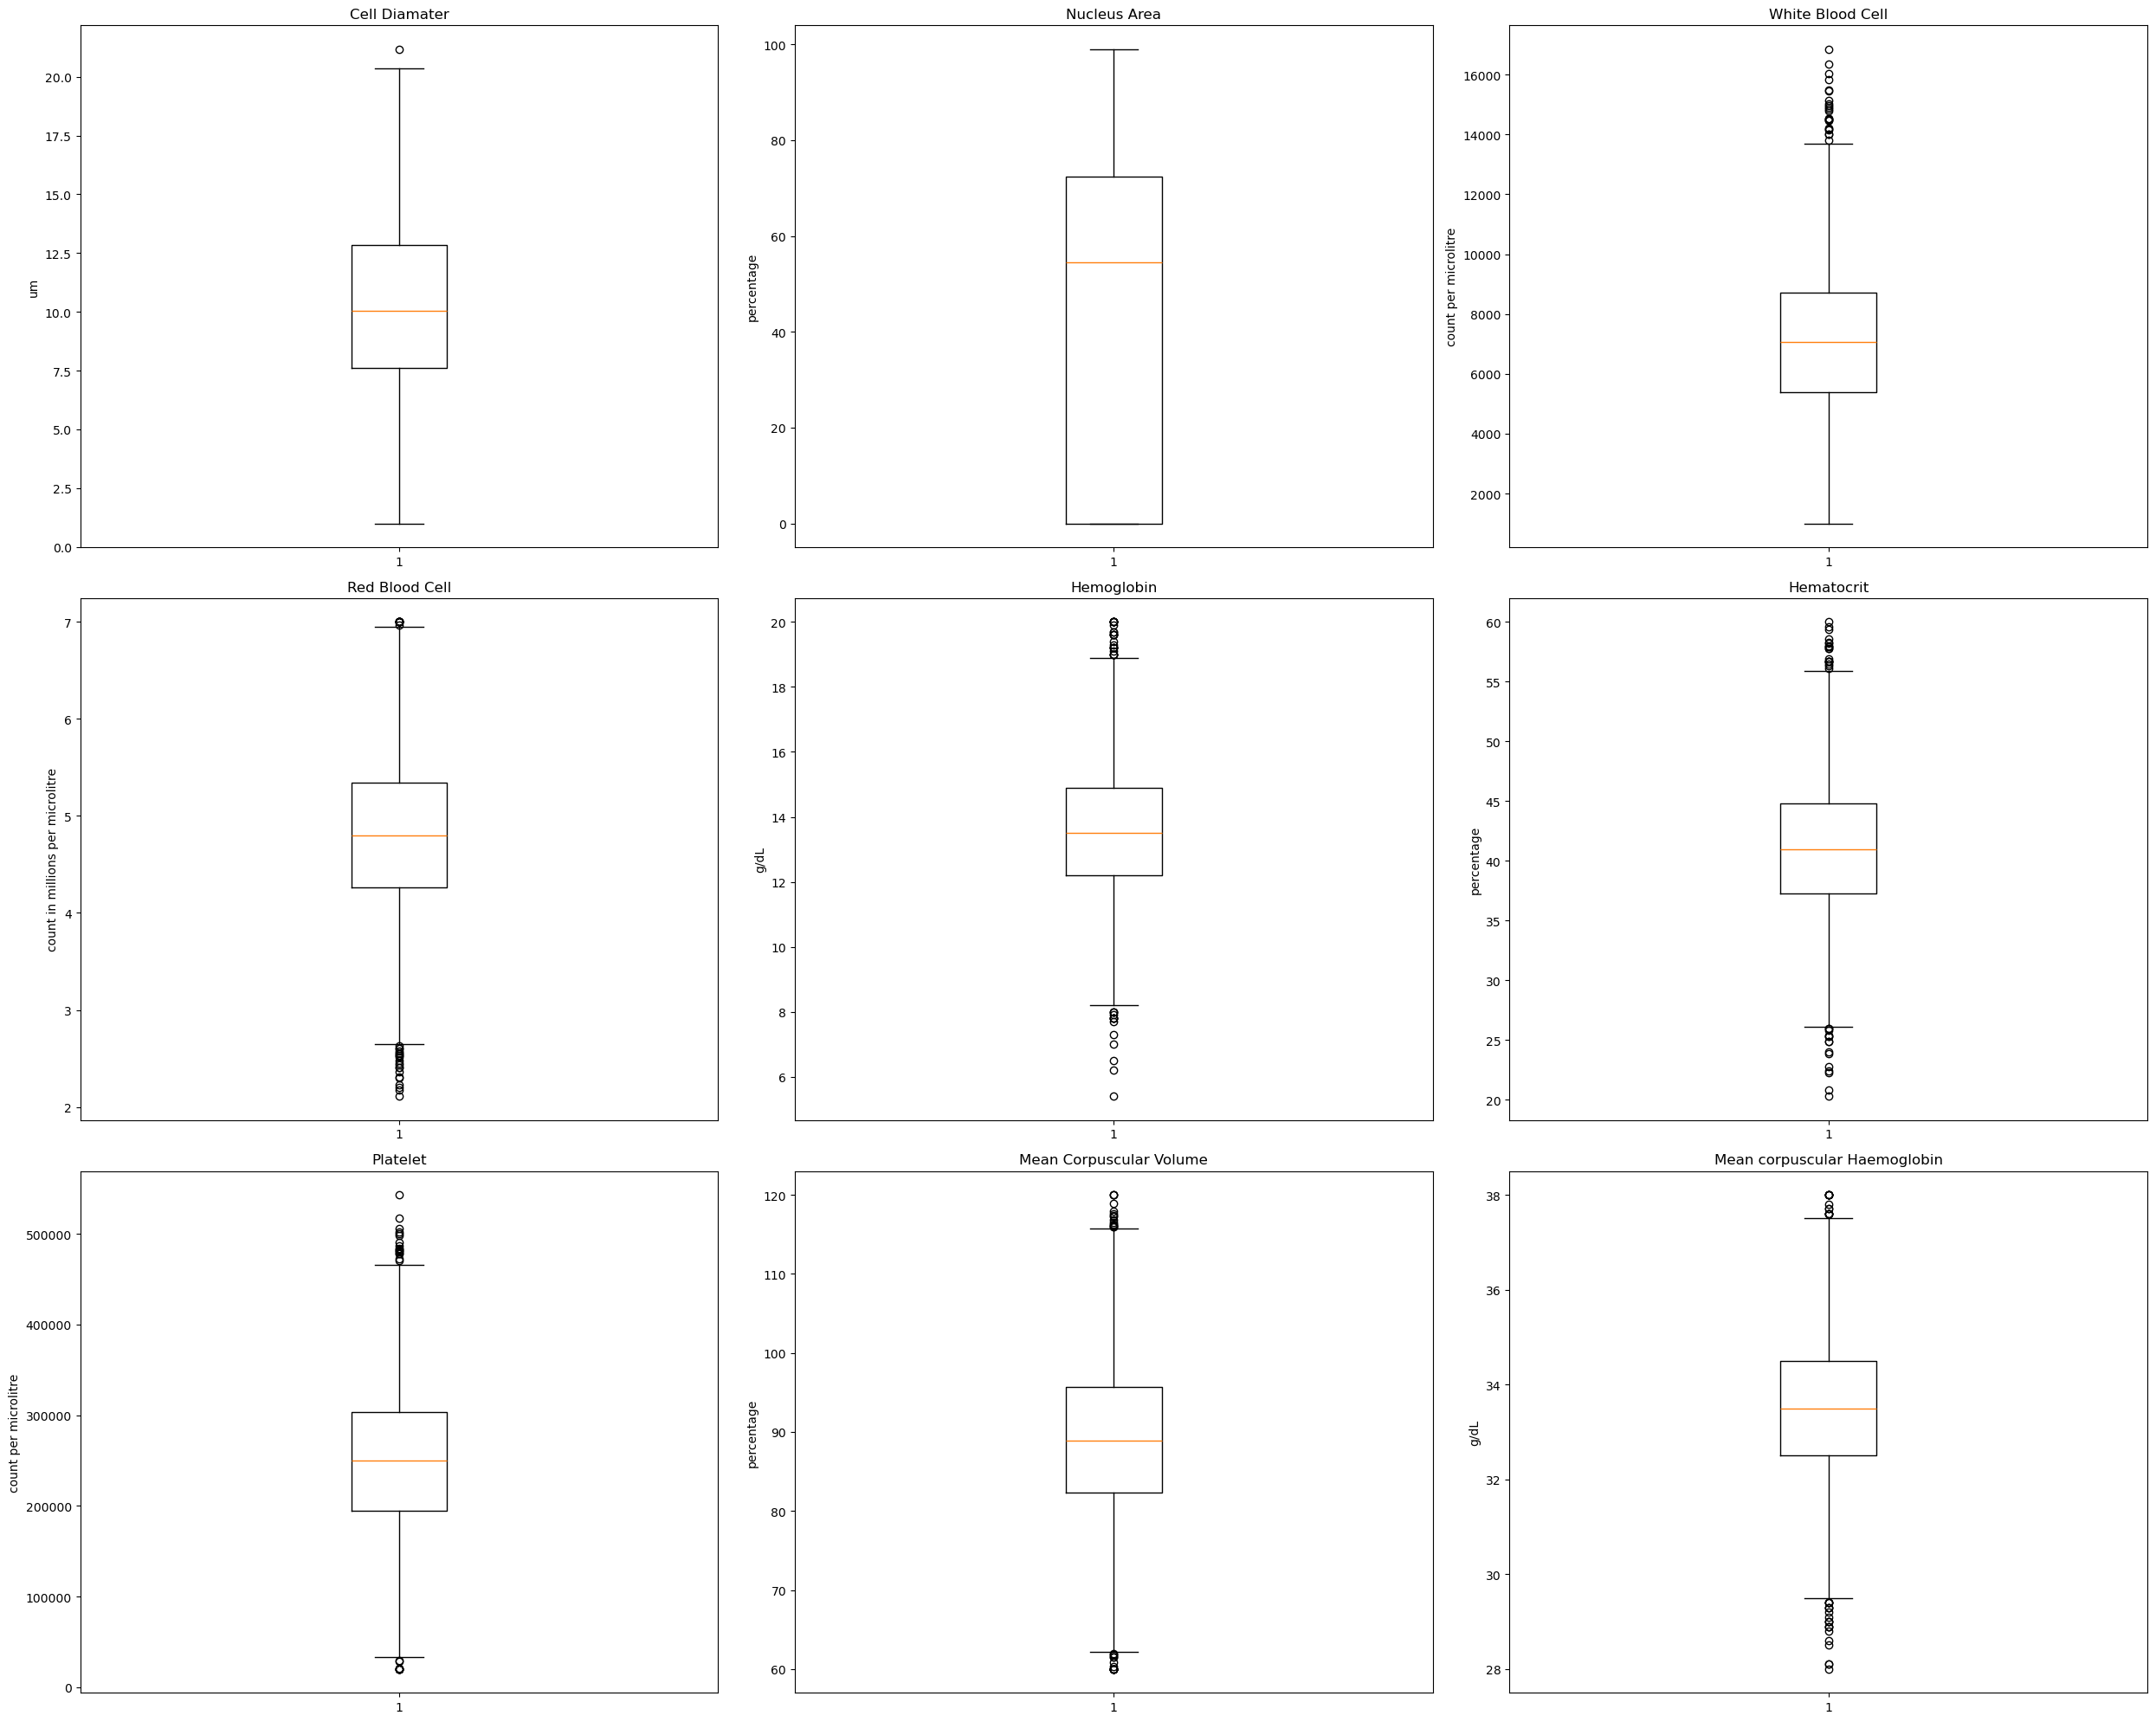

In [145]:
plt.figure(figsize=(25, 20)) 

plt.subplot(3, 3, 1)
plt.title('Cell Diamater')
plt.boxplot(ds['cell_diameter_um'])
plt.ylabel('um')

plt.subplot(3, 3, 2)
plt.title('Nucleus Area')
plt.boxplot(ds['nucleus_area_pct'])
plt.ylabel('percentage')

plt.subplot(3, 3, 3)
plt.title('White Blood Cell')
plt.boxplot(ds['wbc_count_per_ul'])
plt.ylabel('count per microlitre')

plt.subplot(3, 3, 4)
plt.title('Red Blood Cell')
plt.boxplot(ds['rbc_count_millions_per_ul'])
plt.ylabel('count in millions per microlitre')

plt.subplot(3, 3, 5)
plt.title('Hemoglobin')
plt.boxplot(ds['hemoglobin_g_dl'])
plt.ylabel('g/dL')

plt.subplot(3, 3, 6)
plt.title('Hematocrit')
plt.boxplot(ds['hematocrit_pct'])
plt.ylabel('percentage')

plt.subplot(3, 3, 7)
plt.title('Platelet')
plt.boxplot(ds['platelet_count_per_ul'])
plt.ylabel('count per microlitre')

plt.subplot(3, 3, 8)
plt.title('Mean Corpuscular Volume')
plt.boxplot(ds['mcv_fl'])
plt.ylabel('percentage')

plt.subplot(3, 3, 9)
plt.title('Mean corpuscular Haemoglobin')
plt.boxplot(ds['mchc_g_dl'])
plt.ylabel('g/dL')

plt.tight_layout()
plt.show()

Dai grafici, in particolare i boxplot, e dalla tabella generata dal metodo _describe()_ si possono notare alcuni valori outliers per certe features. 
A seguito di analisi e ricerche si è appurato che tali valori sono accettabili e possono ricondursi a casistiche reali. È stato verificato che non vi sia dunque la presenza di valori completamente errati.

Per le features _cell_diameter_um_ e _platelet_count_per_ul_ l'analisi ha evidenziato per ciascuna un singolo elemento outlier che si discosta significativamente dalla distribuzione dei valori.
Risultano essere elementi estremi che potrebbero indurre il modello a errori di apprendimento, compromettendo la sua stabilità.

Quindi, pur trattandosi di dati reali e corretti dal punto di vista clinico, si è scelto di rimuovere questi due specifici record dal dataset prima della fase di modellazione.

In [146]:
ds.drop(ds[ds['cell_diameter_um'] > 20].index, inplace=True)

ds.drop(ds[ds['platelet_count_per_ul'] > 540000].index, inplace=True)

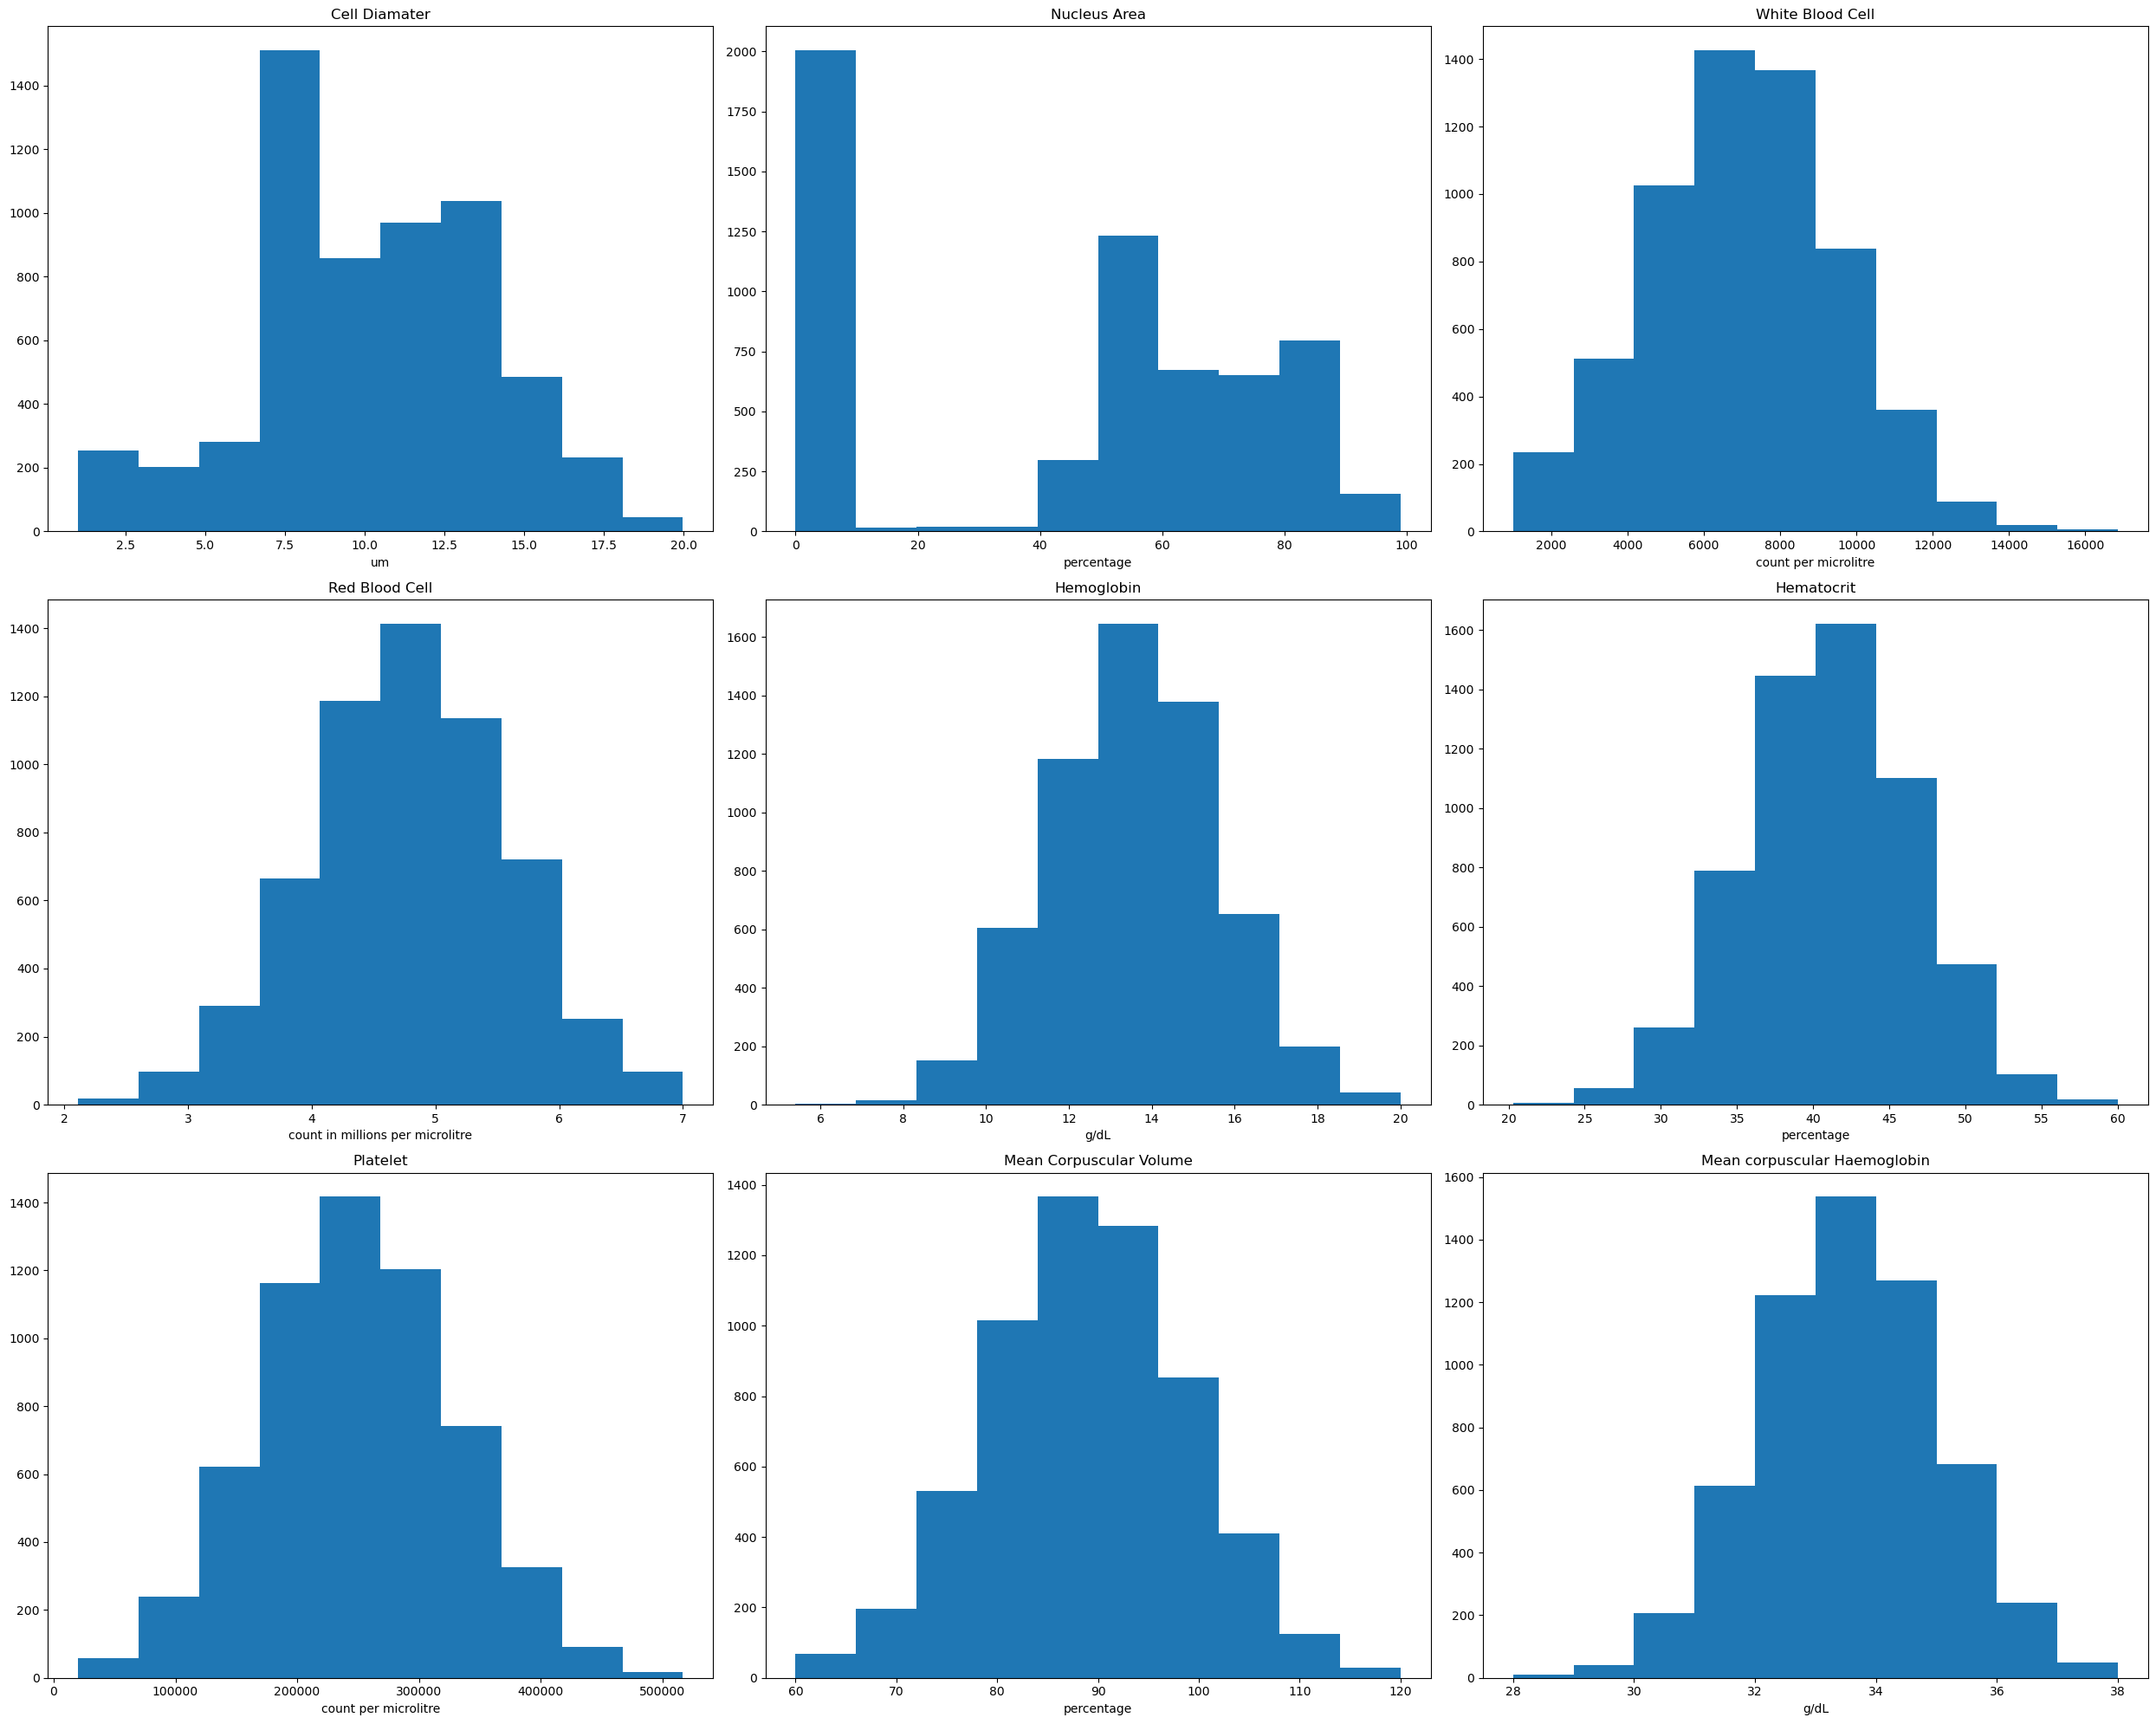

In [147]:
plt.figure(figsize=(25, 20)) 

plt.subplot(3, 3, 1)
plt.title('Cell Diamater')
plt.hist(ds['cell_diameter_um'])
plt.xlabel('um')

plt.subplot(3, 3, 2)
plt.title('Nucleus Area')
plt.hist(ds['nucleus_area_pct'])
plt.xlabel('percentage')

plt.subplot(3, 3, 3)
plt.title('White Blood Cell')
plt.hist(ds['wbc_count_per_ul'])
plt.xlabel('count per microlitre')

plt.subplot(3, 3, 4)
plt.title('Red Blood Cell')
plt.hist(ds['rbc_count_millions_per_ul'])
plt.xlabel('count in millions per microlitre')

plt.subplot(3, 3, 5)
plt.title('Hemoglobin')
plt.hist(ds['hemoglobin_g_dl'])
plt.xlabel('g/dL')

plt.subplot(3, 3, 6)
plt.title('Hematocrit')
plt.hist(ds['hematocrit_pct'])
plt.xlabel('percentage')

plt.subplot(3, 3, 7)
plt.title('Platelet')
plt.hist(ds['platelet_count_per_ul'])
plt.xlabel('count per microlitre')

plt.subplot(3, 3, 8)
plt.title('Mean Corpuscular Volume')
plt.hist(ds['mcv_fl'])
plt.xlabel('percentage')

plt.subplot(3, 3, 9)
plt.title('Mean corpuscular Haemoglobin')
plt.hist(ds['mchc_g_dl'])
plt.xlabel('g/dL')

plt.tight_layout()
plt.show()

Per la maggior parte delle variabili si ha un distribuzione dei valori che somiglia a una curva normale, fatta eccezione per `cell_diameter_um nuclues_area_pct`. Realizziamo dei boxplot per categoria della variabile target per studiarne la dispersione

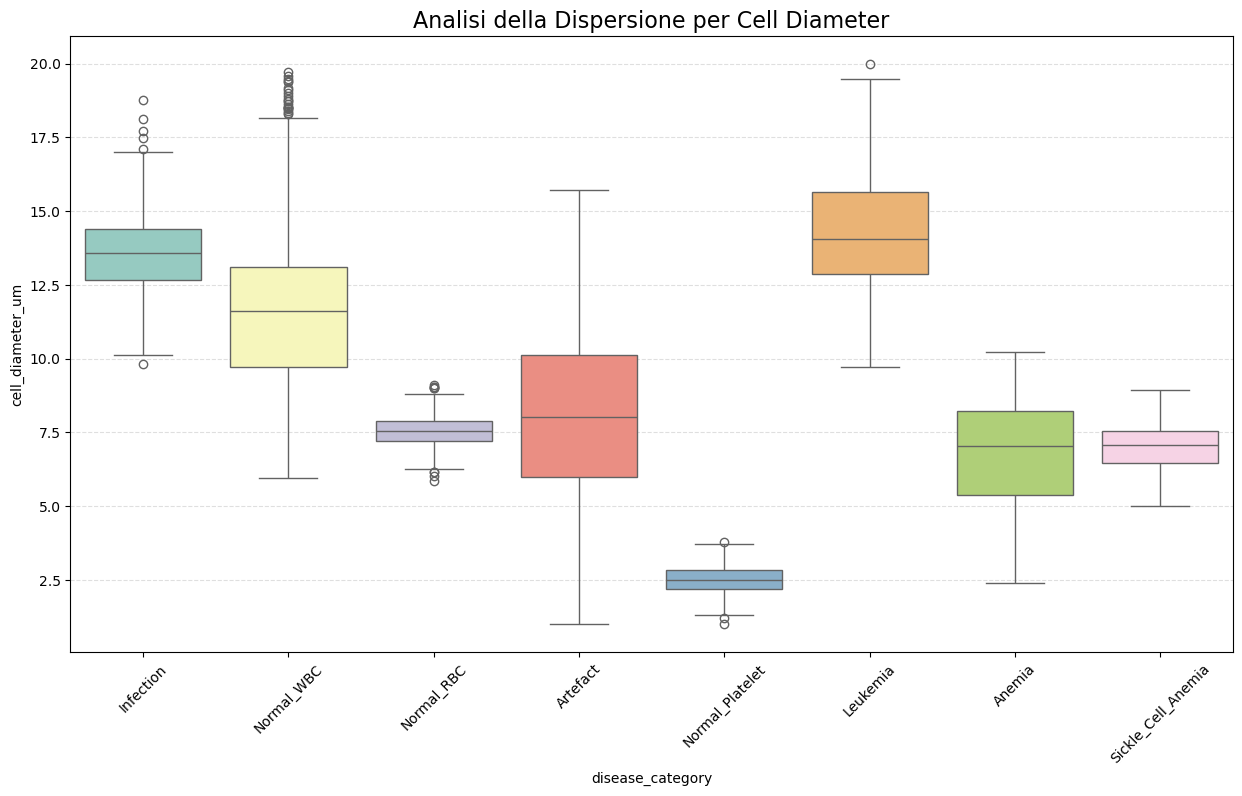

In [148]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=ds, 
    x='disease_category', 
    y='cell_diameter_um', 
    palette='Set3',
    hue='disease_category',
    legend=False
)

plt.title('Analisi della Dispersione per Cell Diameter', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.show()

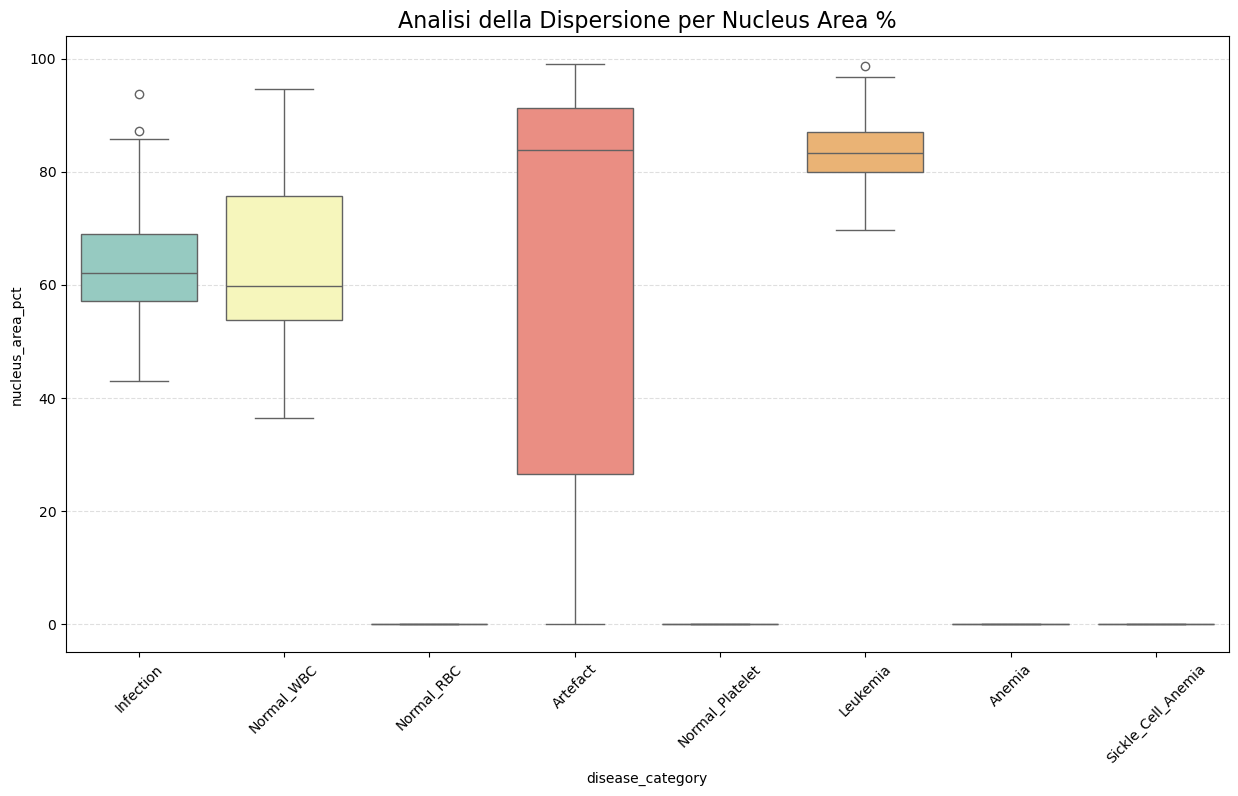

In [149]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=ds, 
    x='disease_category', 
    y='nucleus_area_pct', 
    palette='Set3',
    hue='disease_category',
    legend=False
)

plt.title('Analisi della Dispersione per Nucleus Area %', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.show()

Per entrambe le feature si nota una separazione tra i vari IQR per classe, seppure nel caso di `cell diameter` si abbia comunque un po' di sovrapposizione. Nel caso di nucleus area invece si nota bene, la separazione fra alcune classi come _Normal_RBC_,_Normal_Platelet_,_Anemia_,_Sickle_Cell_Anemia_, che non hanno il nucleo, e _Leukemia_

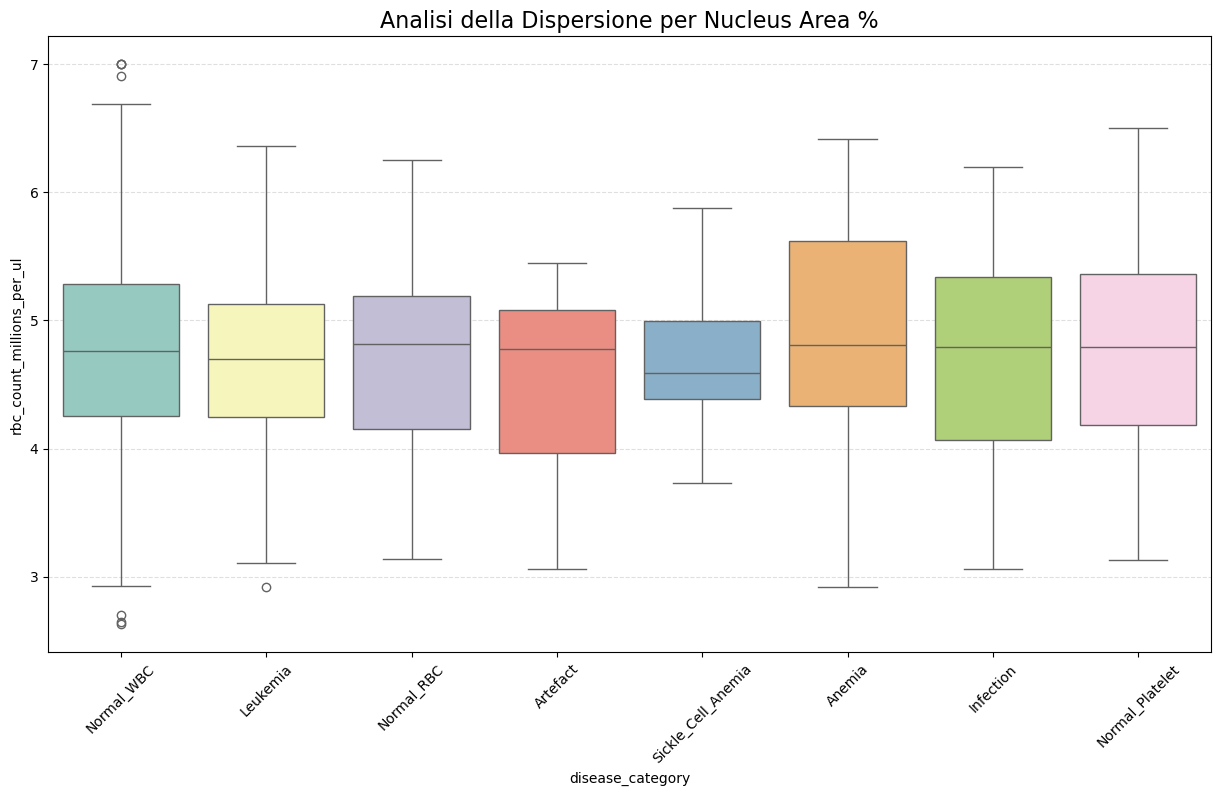

In [150]:
select = (
    (ds["patient_age_group"] == "Pediatric")
    &
    (ds["patient_sex"] == "M")
)
filter_anemia = ds.iloc[select]
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=filter_anemia, 
    x='disease_category', 
    y='rbc_count_millions_per_ul', 
    palette='Set3',
    hue='disease_category',
    legend=False
)

plt.title('Analisi della Dispersione per Nucleus Area %', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.show()

Si procede a realizzare gli istogrammi anche per le altre feature numeriche come punteggi legati a caratteristiche morfologiche della cellula

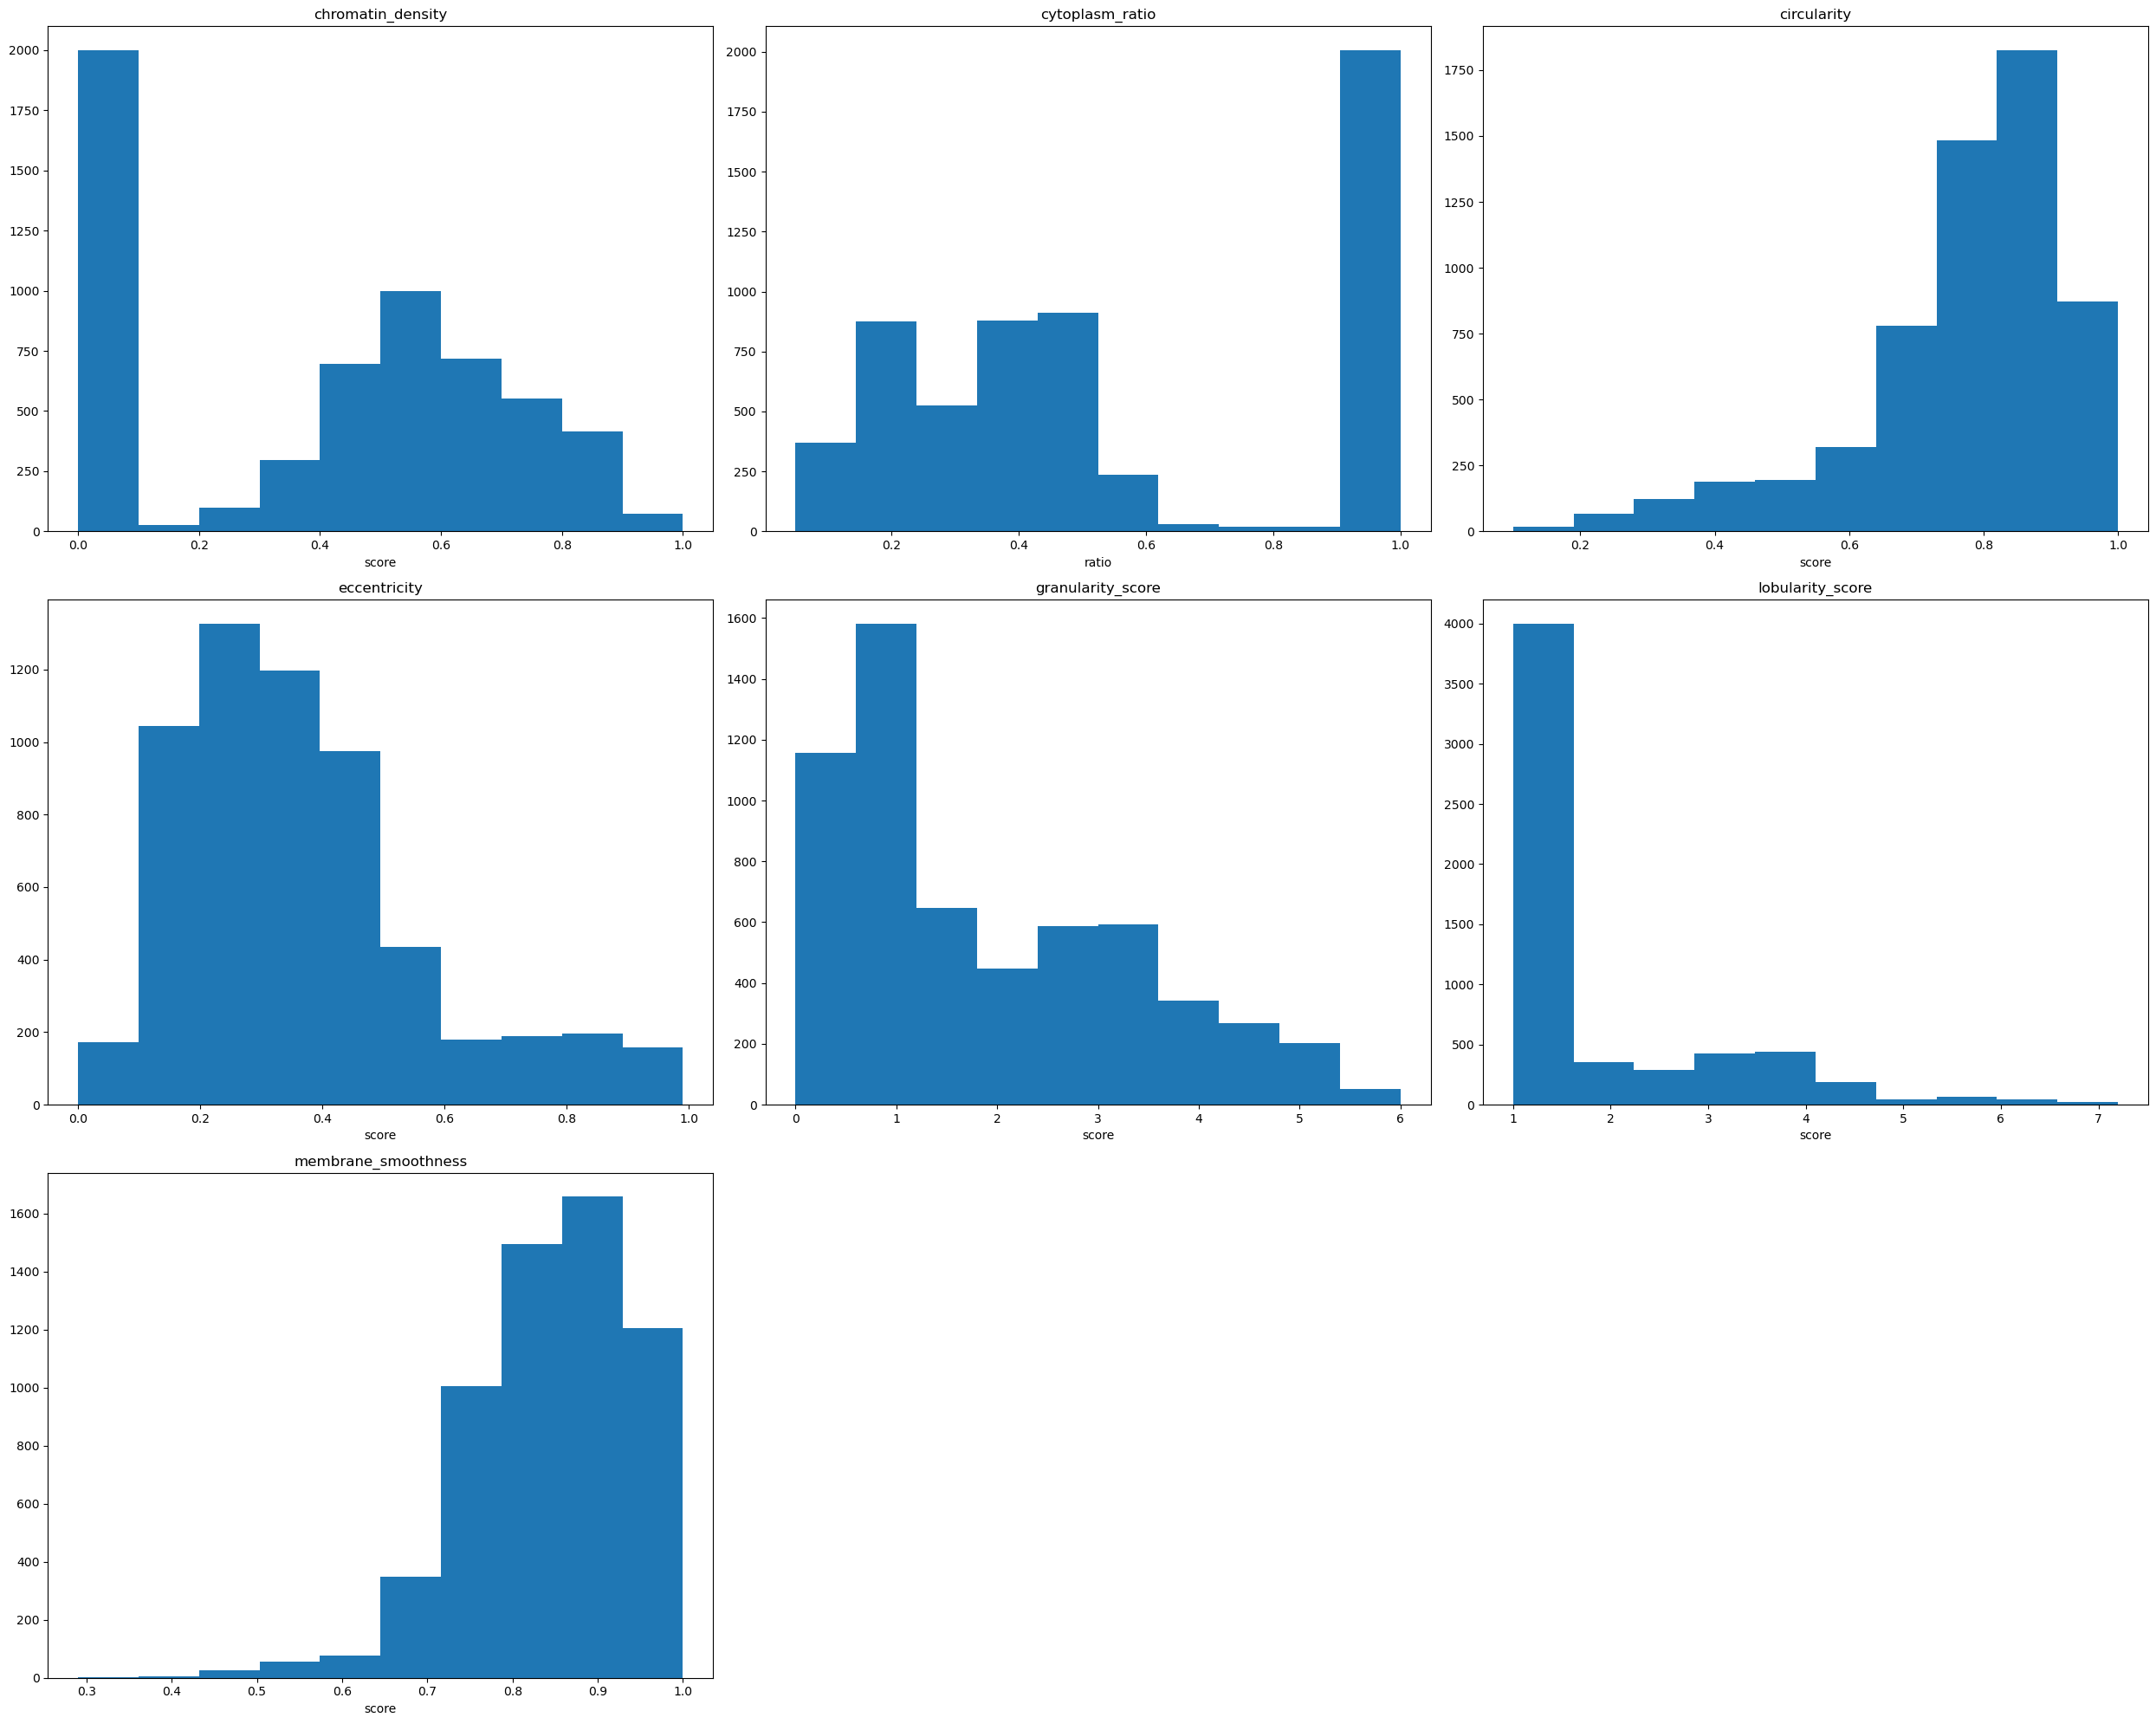

In [151]:
scores = [
    ('chromatin_density', 'score'),
    ('cytoplasm_ratio', 'ratio'),
    ('circularity', 'score'),
    ('eccentricity', 'score'),
    ('granularity_score', 'score'),
    ('lobularity_score', 'score'),
    ('membrane_smoothness', 'score')
]

plt.figure(figsize=(25, 20)) 

for i, (col, label) in enumerate(scores,1):
    plt.subplot(3, 3, i)
    plt.title(col)
    plt.hist(ds[col])
    plt.xlabel(label)

plt.tight_layout()
plt.show()

Gli istogrammi rivelano la presenza di cluster e forti frequenze in alcuni range di valori. Di seguito un'analisi più approfondita mediante boxplot per classe

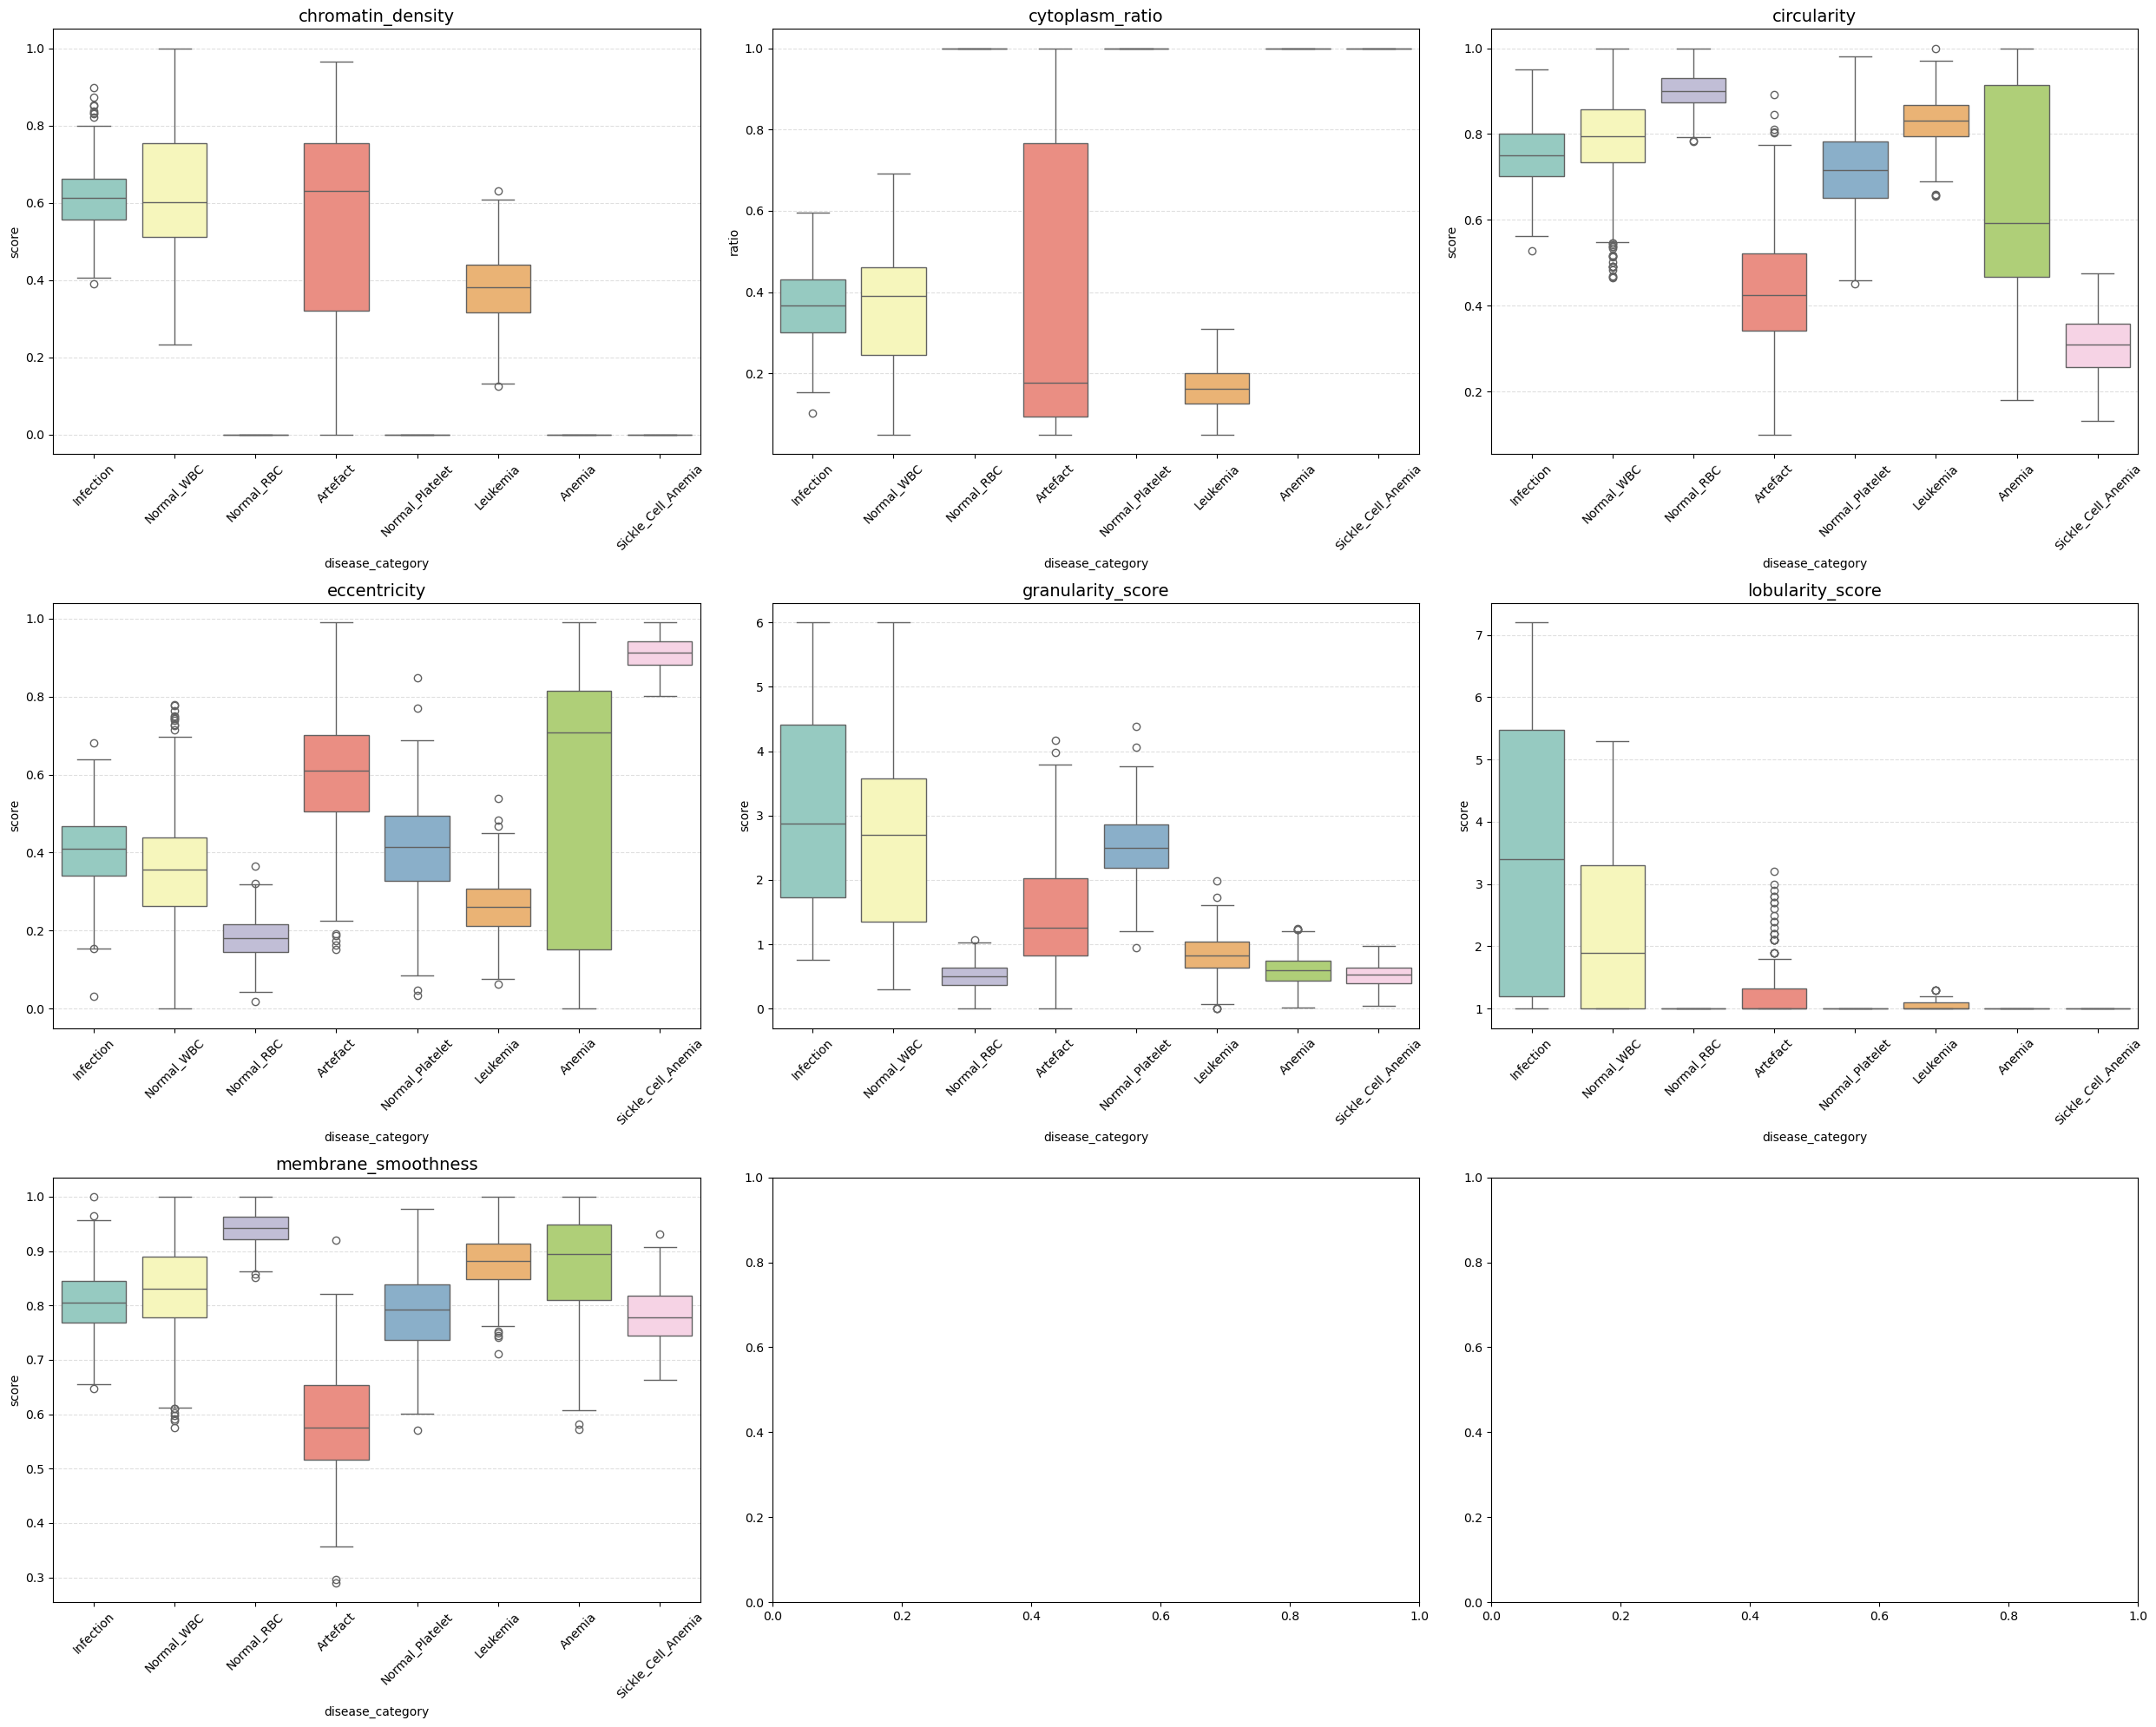

In [152]:
fig, axes = plt.subplots(3, 3, figsize=(25, 20))
axes = axes.flatten()

for i, (col, unit) in enumerate(scores):
    sns.boxplot(
        data=ds,
        x='disease_category',
        y=col,
        palette='Set3',
        hue='disease_category',
        legend=False,
        ax=axes[i]
    )
    
    axes[i].set_title(col, fontsize=14)
    axes[i].set_ylabel(unit)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Si nota generalmente, dai boxplot delle feature, che in base alla classe la distribuzione e dispersione dei valori varia.

In particolare:

*analisi dei singoli boxplot?*

### Analisi feature legate all'immagine

Le feature `cell_area_px perimeter_px mean_r mean_g mean_b microscope_model magnification_x image_resolution_px` sono tutte legate all'immagine della cellula (l'immagine non è presente nel dataset).

In particolare `image_resolution_px` è la dimensione dell'immagine su un asse cartesiano

Si creano gli istogrammi delle feature numeriche legate all'immagine per verificare la presenza di cluster

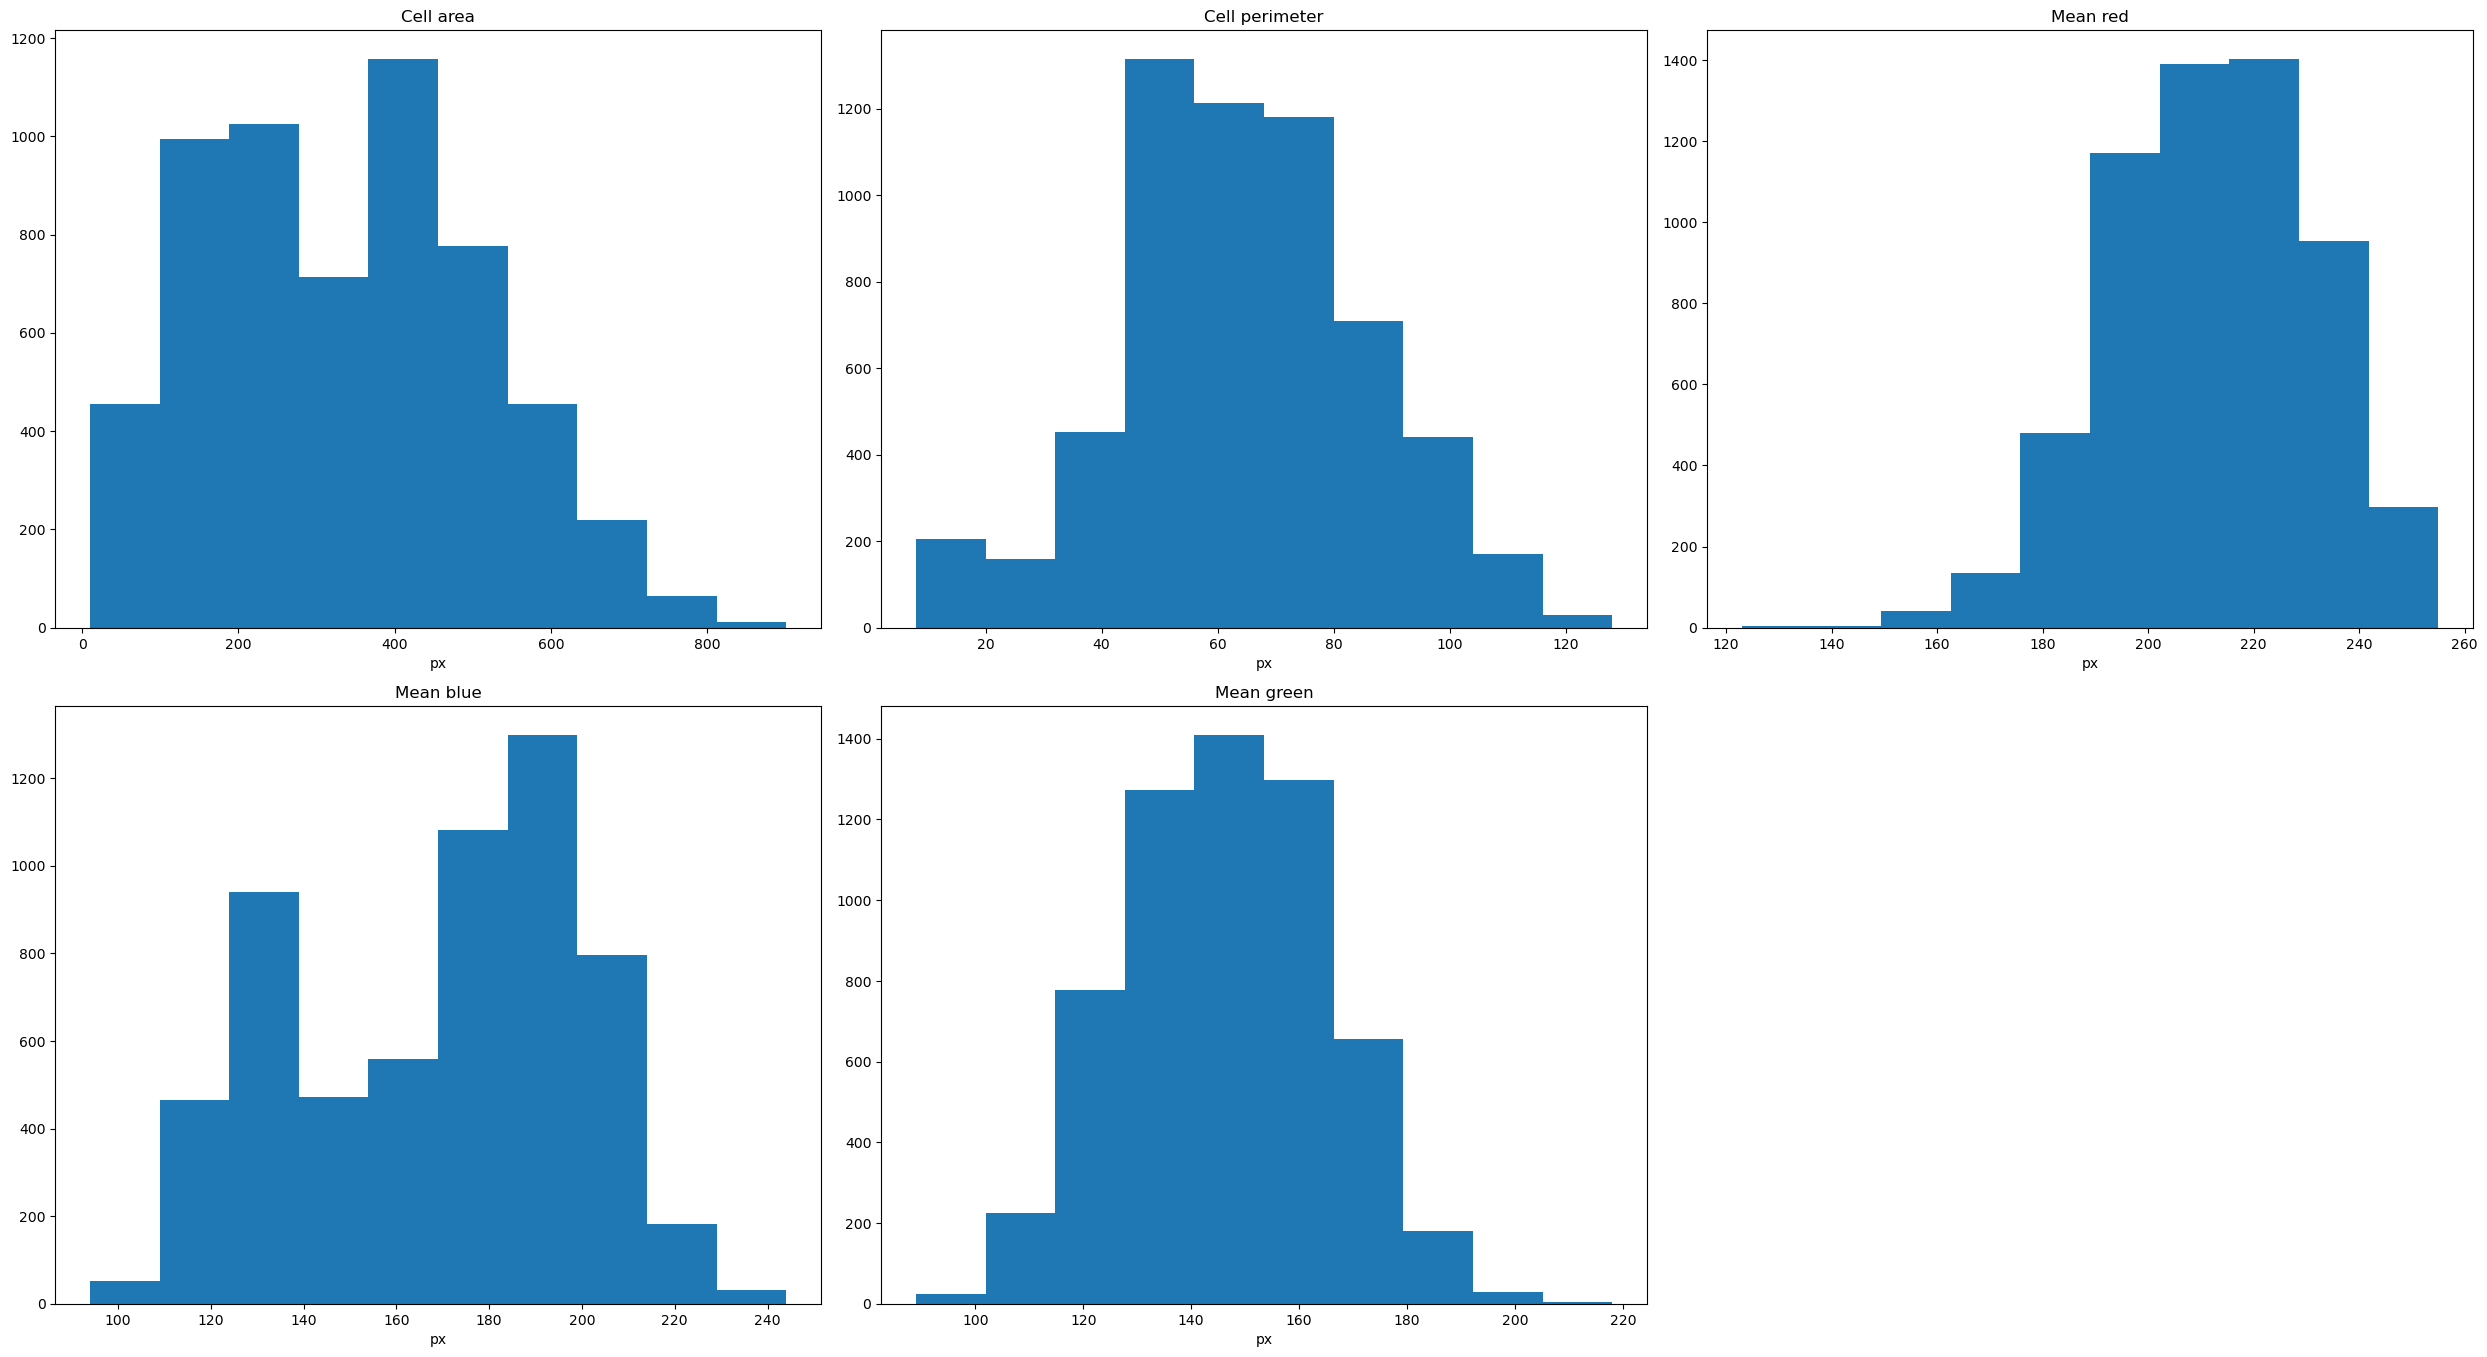

In [153]:
plt.figure(figsize=(25, 20)) 

plt.subplot(3, 3, 1)
plt.title('Cell area')
plt.hist(ds['cell_area_px'])
plt.xlabel('px')


plt.subplot(3, 3, 2)
plt.title('Cell perimeter')
plt.hist(ds['perimeter_px'])
plt.xlabel('px')


plt.subplot(3, 3, 3)
plt.title('Mean red')
plt.hist(ds['mean_r'])
plt.xlabel('px')


plt.subplot(3, 3, 4)
plt.title('Mean blue')
plt.hist(ds['mean_b'])
plt.xlabel('px')


plt.subplot(3, 3, 5)
plt.title('Mean green')
plt.hist(ds['mean_g'])
plt.xlabel('px')

plt.tight_layout()
plt.show()

Le dimensioni in pixel di componenti dell'immagine potrebbe dipendere dagli altri parametri relativi all'acquisizione dell'immagine quali `microscope_model magnification_x image_resolution_px` .
Creando un grafico boxplot per categorie si possono notare differenze nella distribuzione dei valori

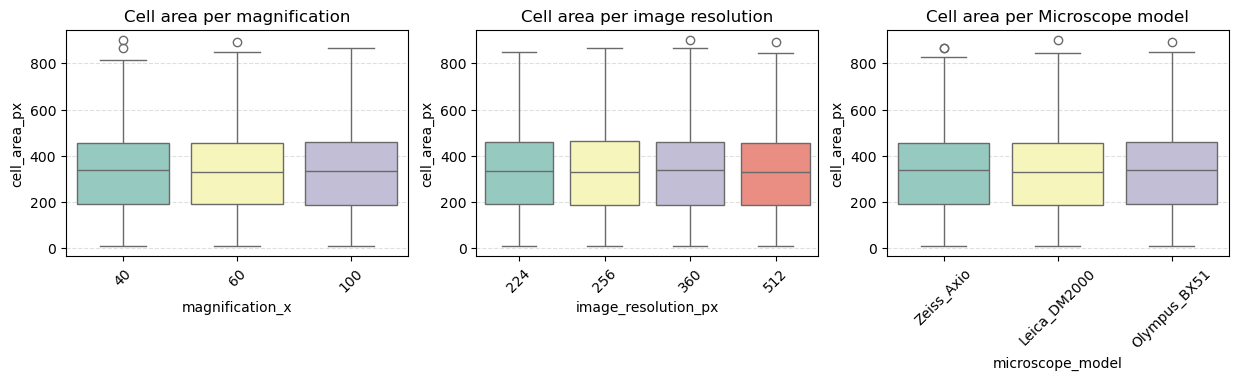

In [154]:
plt.figure(figsize=(15, 10))

plt.subplot(3,3,1)

sns.boxplot(
    data=ds, 
    x='magnification_x', 
    y='cell_area_px', 
    palette='Set3',
    hue='magnification_x',
    legend = False
)

plt.title('Cell area per magnification')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.subplot(3,3,2)

sns.boxplot(
    data=ds, 
    x='image_resolution_px', 
    y='cell_area_px', 
    palette='Set3',
    hue='image_resolution_px',
    legend = False
)

plt.title('Cell area per image resolution')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)

plt.subplot(3,3,3)

sns.boxplot(
    data=ds, 
    x='microscope_model', 
    y='cell_area_px', 
    palette='Set3',
    hue='microscope_model',
    legend = False
)

plt.title('Cell area per Microscope model')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.show()

Dai grafici si apprende che le caratteristiche relative all'acquisizione non hanno incidenza sulla distribuzione dei dati e che quindi `cell_area_px` non dipenda da queste variabili. Questo può essere dovuto al fatto che la feature `cell_area_px` fosse già stata normalizzata nel dataset o che siano state applicate altre forme di scaling o preprocessing dei dati

Le cellule malate potrebbero differire tra di loro per dimensione. Realizziamo un boxplot
diviso per classe `disease_category` per vedere se la dispersione dei dati varia in base
alla classe

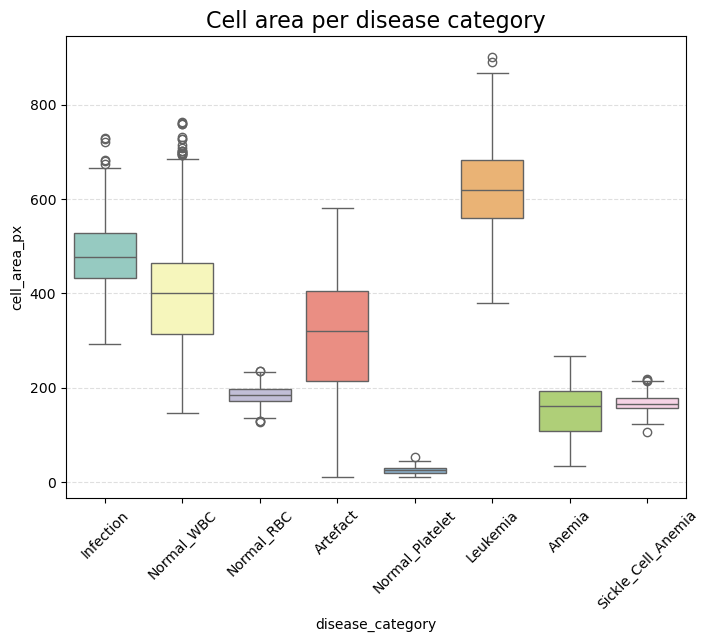

In [155]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=ds, 
    x='disease_category', 
    y='cell_area_px', 
    palette='Set3',
    hue='disease_category'
)
plt.title('Cell area per disease category', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.show()

Notiamo che in base alla classe si ha una notevole differenza nella distribuzione dei valori. Le classi differiscono fra loro nelle mediane e dimensioni dei range interquantili. 

Questo ci suggerisce che la feature potrebbe essere informativa per predire la variabile target

Si suppone inoltre che ci sia una correlazione tra `perimeter_px` e `cell_area_px`. Calcoliamo l'indice di correlazione

In [156]:
correlation_df = ds[['cell_area_px' ,'perimeter_px']].corr()
print(correlation_df.iloc[1,0])

0.8625737765347631


Si nota una forte correlazione, quindi si può presupporre che anche `perimeter_px` possa essere molto determinante
nella predizione. 

Si realizza uno scatter plot per individuare meglio la presenza di cluster

In [157]:
disease_color_map = {"Leukemia" : "red",
                    "Anemia" : "orange",
                    "Sickle_Cell_Anemia" : "yellow",
                    "Infection" : "green",
                    "Artefact" : "black"}

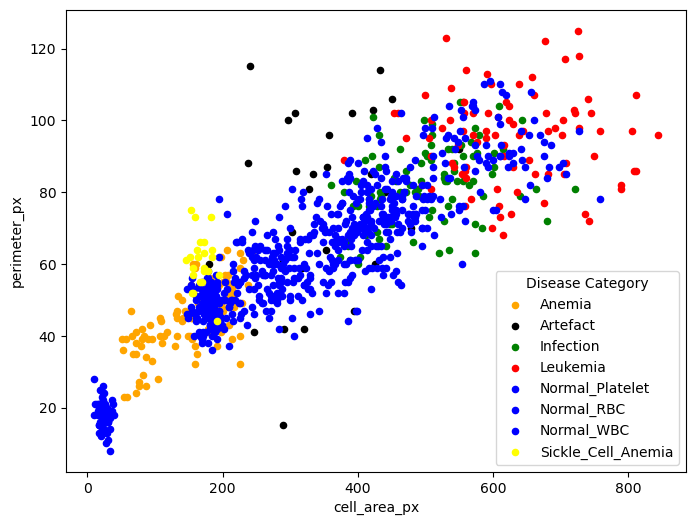

In [158]:
sample = ds.sample(1000) 

fig, ax = plt.subplots(figsize=(8, 6))

for category, group in sample.groupby("disease_category"):
    color = disease_color_map.get(category, "blue")
    
    group.plot.scatter(
        x="cell_area_px", 
        y="perimeter_px", 
        c=color, 
        label=category,
        ax=ax
    )

ax.legend(title="Disease Category")

Si nota la formazione di cluster per alcune categorie di malattie. Si presuppone quindi che queste feature possano essere determinanti per la predizione della variabile target

## Collinearità e relazione tra variabili

Calcoliamo gli indici di collinearità fra le feature numeriche del dataset per comprendere quali feature sono correlate e dunque hanno una relazione di dipendenza le une dalle altre

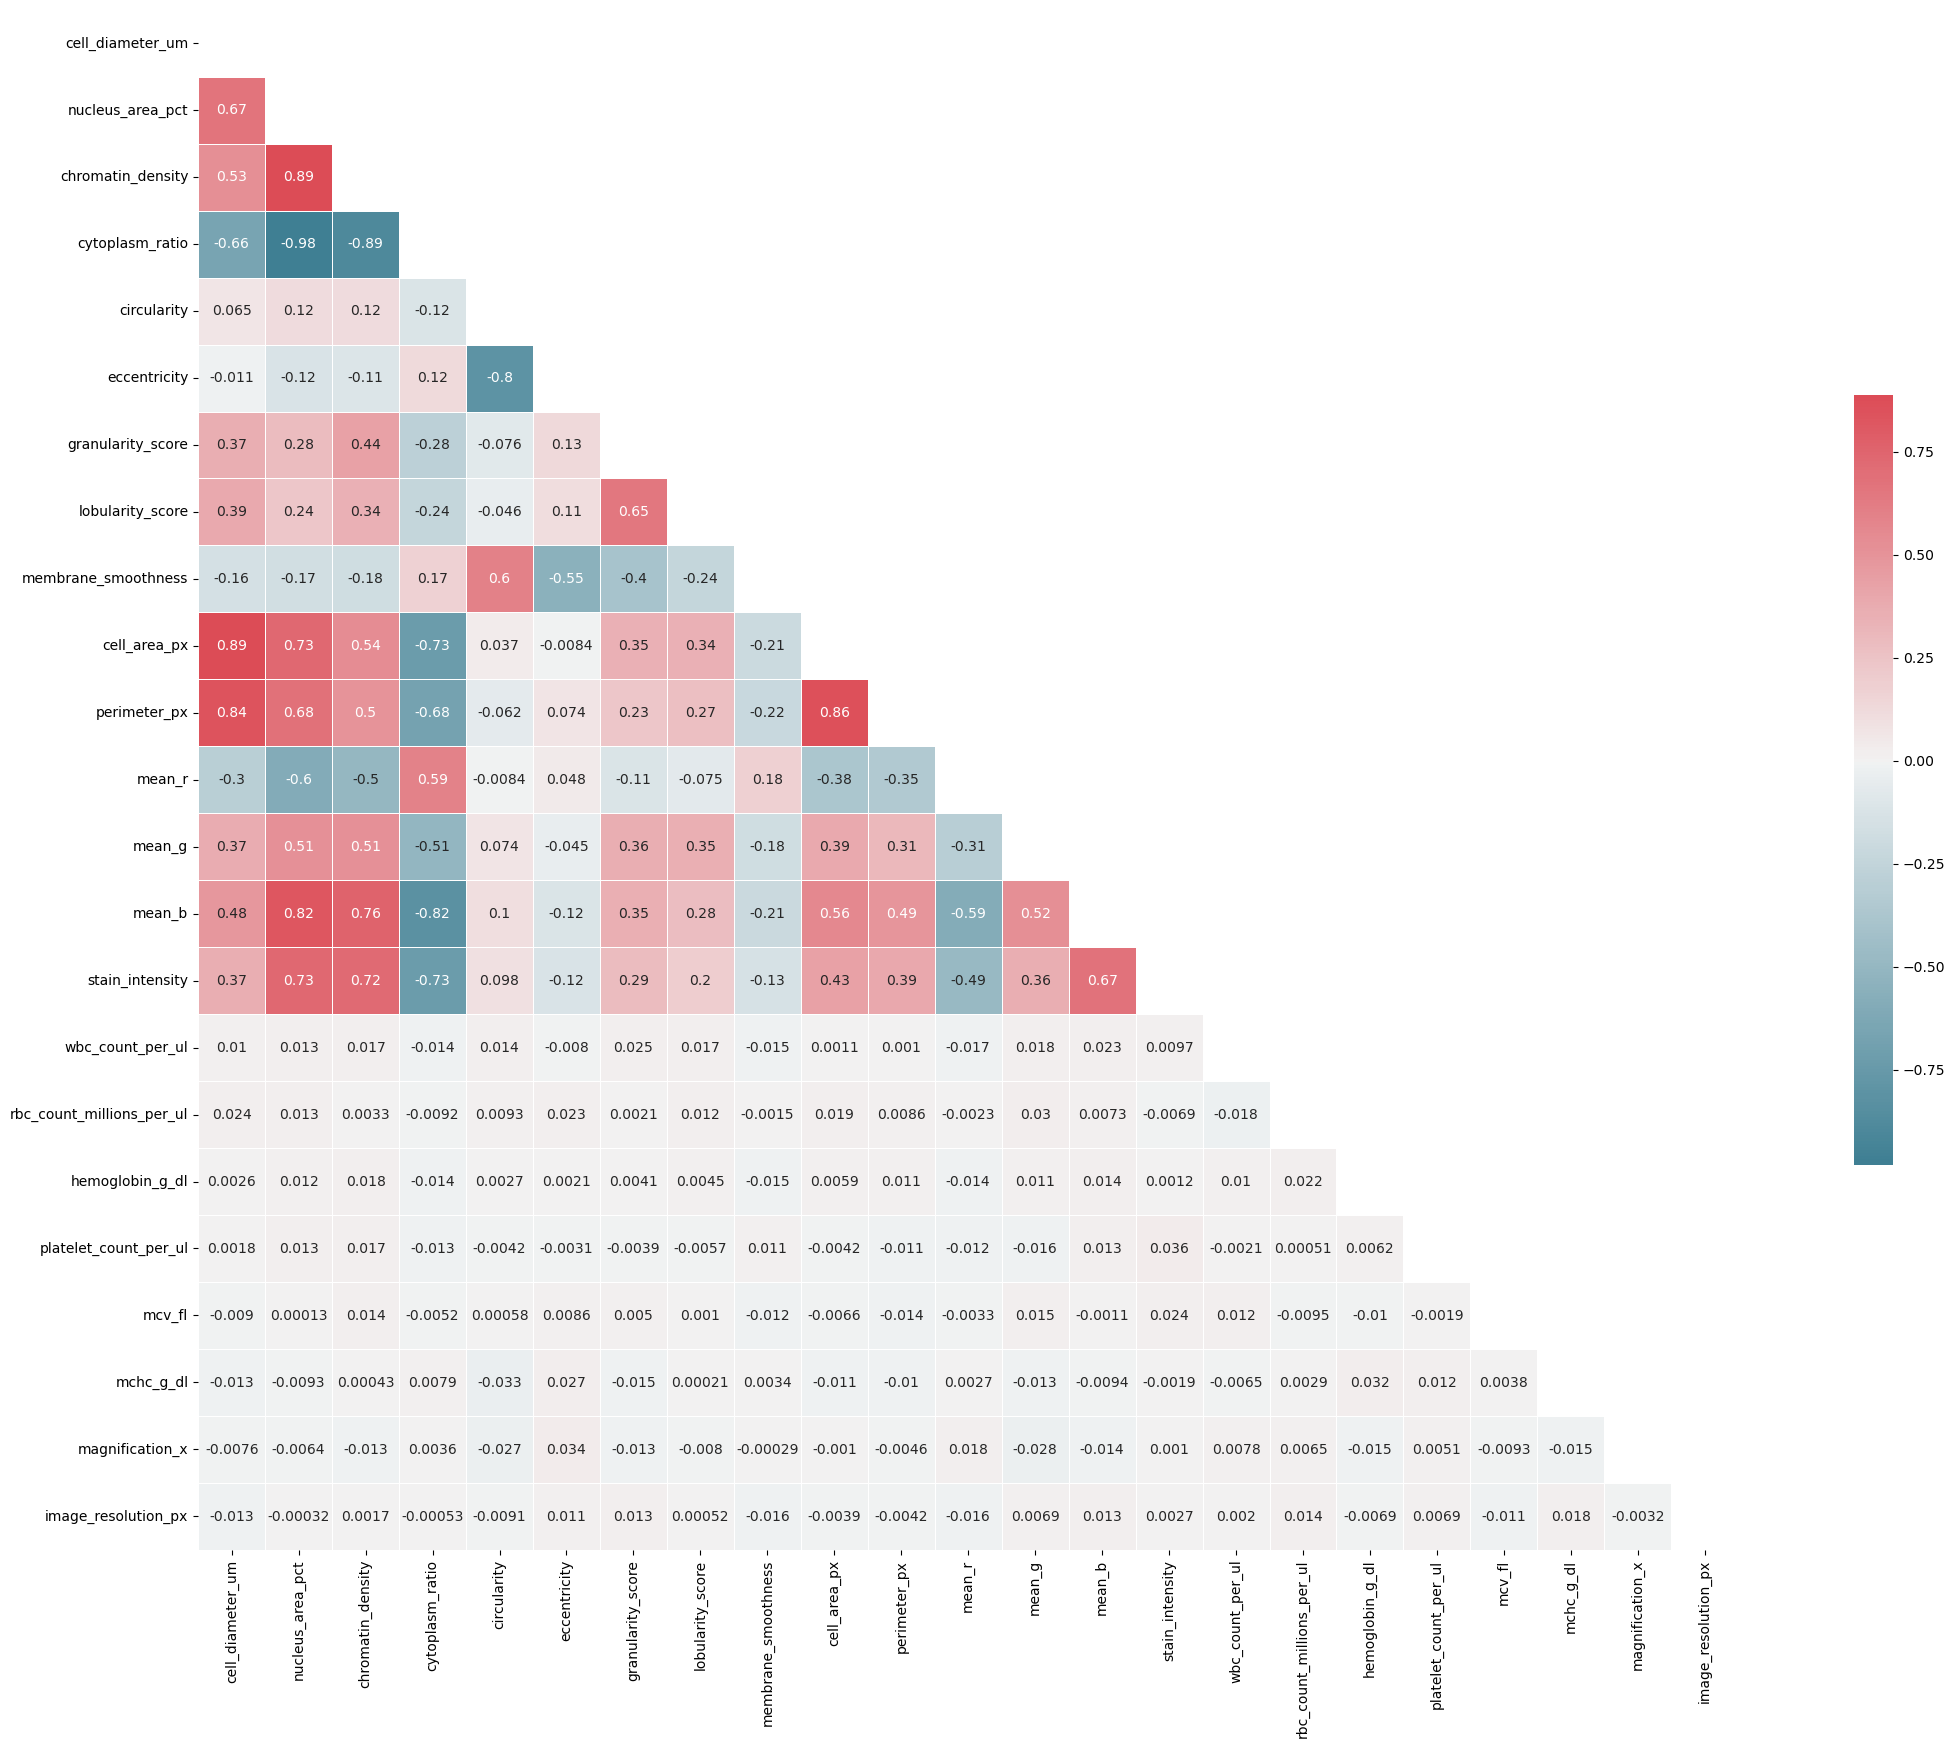

In [159]:
numerical_features = [
    'cell_diameter_um',
    'nucleus_area_pct',
    'chromatin_density',
    'cytoplasm_ratio',
    'circularity',
    'eccentricity',
    'granularity_score',
    'lobularity_score',
    'membrane_smoothness',
    'cell_area_px',
    'perimeter_px',
    'mean_r',
    'mean_g',
    'mean_b',
    'stain_intensity',
    'wbc_count_per_ul',
    'rbc_count_millions_per_ul',
    'hemoglobin_g_dl',
    'platelet_count_per_ul',
    'mcv_fl',
    'mchc_g_dl',
    'magnification_x',
    'image_resolution_px']

correlations = ds[numerical_features].corr()
cmap = sns.diverging_palette(220, 10, as_cmap=True)
mask = np.zeros_like(correlations, dtype=np.bool)    
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(30, 20))
sns.heatmap(correlations, mask=mask, cmap=cmap, center=0,annot = True, square=True, linewidths=.5, cbar_kws={"shrink": .5});

Dalla tabella notiamo come tutte le feature al di sotto della riga `stain_intensity` 
abbiano poca correlazione con il resto del dataset. Già dagli istogrammi si poteva osservare come queste feature assumessero una distribuzione alquanto più simile a una gaussiana e che quindi probabilmente tali variabili assumessero una distribuzione normale e dunque indipendente da altri fattori

Sempre guardando la matrice di correlazione si notano le seguenti relazioni:

* `chromatin_density` e `nucleus_area_pct` : Questo risultato sembra sottolineare un possibile errore nei dati. Infatti, le due feature dovrebbero essere legate da una collinearità inversa, perchè più piccolo il nucleo maggiore dovrebbe essere la densità della cromatina (che è contenuta solo nel nucleo della cellula). È necessario fare ulteriori investigazioni per comprendere il significato di questo risultato, si sottolinea anche che `nucleus_area_pct` non è la dimensione assoluta del nucleo, ma è un dato che dipende dalla dimensione della cellula
* `cytoplasm_ratio` e `nucleus_area_pct` : le due feature sono inversamente correlate, era un risultato atteso in quanto il citoplasma occupa la parte di cellula non contenuta nel nucleo. Maggiore la dimensione del nucleo, minore lo spazio rimanente
* `cytoplasm_ratio` vs `chromatin_density` : Sempre a seguito delle osservazioni fatte su `chromatin_density` e `nucleus_area_pct` e `cytoplasm_ratio` e `nucleus_area_pct` si deduce come in realtà questo rislutato possa apparire come apparentemente errato
* `eccentricty` e `circularity` : i due punteggi hanno semanticamente significati opposti, è quindi atteso che ci fosse una collinearità inversa
* `cell_area_px` e `cell_diameter_um` : L'aumentare della misura del diametro è perfettamente in linea con una maggiore dimensione in pixel della cellula nella foto, si rammenta che i valori in pixel sono già stati normalizzati e non dipendono dall'immagine  
* `perimeter_px` e `cell_diameter_um` : Discorso analogo all'area della cellula
* `perimeter_px` e `cell_area_px`: Come mostrato in precedenza, cellule più grandi in termini di area corrispondono a un perimetro maggiore
* `mean_b`e `nucleus_area_pct`: Le immagini del dataset sono state acquisite a seguito del procedimento _Wright-Giemsa_ di macchiatura. Questa tecnica risalta i cromosomi nell'immagine colorandoli di blu. Un nucleo più grande implica che i cromosomi occupino più spazio nella foto, di conseguenza il colore blu sarà maggiormente predominante e questo porta ad alzare la media del valore del canale blu nella foto
* `mean_b` e `cytoplasm_ratio` : a partire dalla relazione fra `mean_b`e `nucleus_area_pct` e `cytoplasm_ratio` e `nucleus_area_pct` si può comprendere il perchè queste feature siano inversamente collineari

Si suppone che le feature `chromatin_density` e `nucleus_area_pct` abbiano un valore di collinearità così elevato perchè si ha una forte concentrazione di istanze attorno al valore 0, in entrambe le feature. Queste istanze sono date principalmente da piastrine (platelets) e globuli rossi che non hanno un nucleo. Analogalmente non avendo un nucleo queste cellule avranno anche un valore di cromatina vicino allo 0

In [160]:
ds[(ds.nucleus_area_pct == 0)][['cell_type','disease_category','nucleus_area_pct','chromatin_density']]

,cell_type,disease_category,nucleus_area_pct,chromatin_density
3,Normal_RBC,Normal_RBC,0.0,0.0
4,Normal_RBC,Normal_RBC,0.0,0.0
12,Normal_RBC,Normal_RBC,0.0,0.0
13,Platelet,Normal_Platelet,0.0,0.0
14,Normal_RBC,Normal_RBC,0.0,0.0
...,...,...,...,...
5868,Normal_RBC,Normal_RBC,0.0,0.0
5874,Normal_RBC,Normal_RBC,0.0,0.0
5875,Platelet,Normal_Platelet,0.0,0.0
5876,Target_Cell,Anemia,0.0,0.0


Si prova a fare uno studio della collinearità più approfondito escludendo queste cellule

,chromatin_density,nucleus_area_pct
chromatin_density,1.000000,0.284887
nucleus_area_pct,0.284887,1.000000


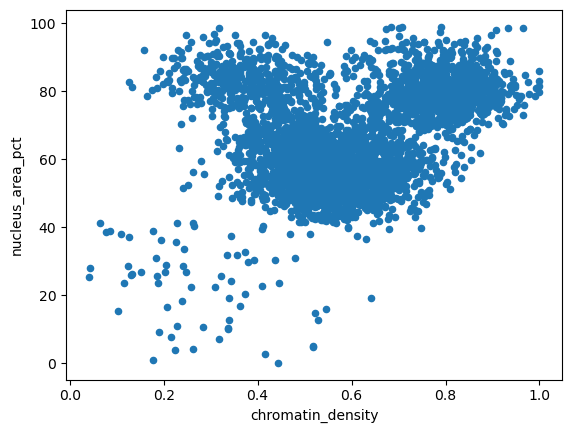

In [161]:
cells_wit_nucleus = ds[(ds.chromatin_density != 0) & (ds.nucleus_area_pct != 0)]
cells_wit_nucleus.plot.scatter("chromatin_density", "nucleus_area_pct")
cells_wit_nucleus[['chromatin_density','nucleus_area_pct']].corr()

Si nota che il valore di correlazione è calato drasticamente, guardando il nuovo valore si potrebbe dire che le feature sono debolmente correlate.

Andando più a fondo si evidenzia come nucleus_area_pct, per definizione, non è una misura assoluta della dimensione del nucleo bensì relativa aslla dimensione totale della cellula. Invece la densità della cromatina dovrebbe dipendere dalla dimensione del nucleo in termini assoluti. Non è quindi informativo svolgere un confronto diretto tra le due variabili. Ad esempio, alcune cellule potrebbero avere un nucleo molto grande rapportato al volume totale (`nucleus_area_pct` alto) pur rimanendo cellule "piccole" con un nucleo "piccolo" e quindi avere valori di cromatina alti.

Si prova a stimare una misura assoluta delle dimensioni del nucleo, creando una feature calcolata, e si esegue un'ulteriore analisi.

In [162]:
nucleus_area_px = ((cells_wit_nucleus.nucleus_area_pct/100) * cells_wit_nucleus.cell_area_px)

In [163]:
cells_wit_nucleus.insert(1,'nucleus_area_px',nucleus_area_px) 

,chromatin_density,nucleus_area_px
chromatin_density,1.000000,-0.410475
nucleus_area_px,-0.410475,1.000000


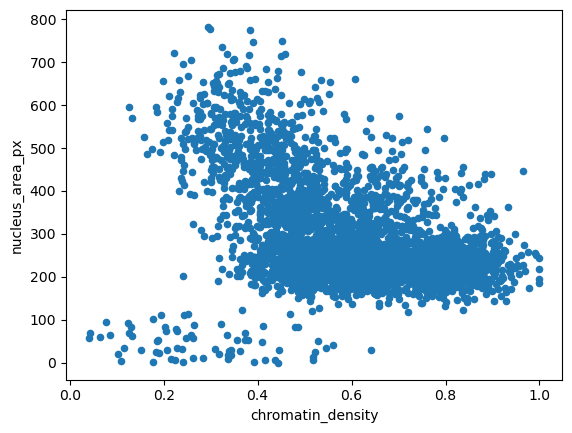

In [164]:
cells_wit_nucleus.plot.scatter("chromatin_density", "nucleus_area_px")
cells_wit_nucleus[['chromatin_density','nucleus_area_px']].corr()

Le due variabili risultano essere moderatamente correlate negativamente, e questo risultato è in linea con il comportamento che la scienza ci dice dovrebbe verificarsi. 

Da questo si deduce che la forte correlazione che avevamo osservato in origine è in realtà un artefatto dovuto alla distribuzione dei dati molto sbilanciata verso lo 0 per le due feature, dovuta a quelle tipologie di cellule che non hanno un nucleo. 

Si procede a mantenere il dataset nello stato corrente verrà poi osservato nella fase di allenamento l'incidenza delle feature ed eventualmente si progetteranno soluzioni che considerano questo problema con il fine di migliorare l'accuratezza dei modelli.

Eventualmente, si potrebbe considerare l'introduzione della variabile calcolata `nucleus_area_px`

# Parte 3 - Preparazione dei dati

Si preparano ora i dati per essere elaborati dal modello.

Si eliminano le features _anomaly_label_ e _cell_type_ poichè porterebbero ad un'apprendimento diretto. L'obiettivo del nostro modello è predire la _disease_category_ date le informazioni strettamente legate alla analisi della cellula, e non predire la malattia conoscendo giè il tipo di cellula o se l'elemento stesso è anomalo.

Si procede inoltre a isolare anche la variabile target _disease_cateogry_ da predire.

In [165]:
target = ds['disease_category']
ds.drop(columns=['disease_category', 'anomaly_label', 'cell_type'], inplace=True)

In [166]:
to_encode = ['patient_age_group',
                'patient_sex',
                'staining_protocol',
                 'microscope_model',
                 'magnification_x',
                 'image_resolution_px',]

ds = pd.get_dummies(ds, columns=to_encode, dtype=int)

Essendo presenti features categoriche si procede a processare i dati attraverso il One-Hot Encoding

In [167]:
target.info()

<class 'pandas.Series'>
Index: 5875 entries, 0 to 5879
Series name: disease_category
Non-Null Count  Dtype
--------------  -----
5875 non-null   str  
dtypes: str(1)
memory usage: 148.2 KB


In [168]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(ds, target, test_size=0.3, random_state=43, stratify=target)

In [169]:
y_train.head()

757             Normal_WBC
856             Normal_WBC
5869             Infection
133             Normal_RBC
3185    Sickle_Cell_Anemia
Name: disease_category, dtype: str

In [170]:
X_train.head()

,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,patient_age_group_Adult,patient_age_group_Elderly,patient_age_group_Pediatric,patient_sex_F,patient_sex_M,staining_protocol_Giemsa,staining_protocol_May_Grunwald_Giemsa,staining_protocol_Wright,microscope_model_Leica_DM2000,microscope_model_Olympus_BX51,microscope_model_Zeiss_Axio,magnification_x_40,magnification_x_60,magnification_x_100,image_resolution_px_224,image_resolution_px_256,image_resolution_px_360,image_resolution_px_512
757,11.67,56.7,0.734,0.449,0.824,0.328,4.14,1.9,0.779,352,69,209,132,188,0.816,3902,4.80,9.8,39.6,252871,80.7,34.0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0
856,15.26,57.5,0.493,0.370,0.561,0.392,1.34,1.6,0.777,657,108,211,161,182,0.535,4991,5.20,15.4,40.5,253839,96.9,34.8,1,0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0
5869,13.91,71.9,0.536,0.274,0.938,0.195,1.73,1.1,0.831,557,95,189,115,198,0.685,7558,6.58,17.6,42.9,258346,100.8,34.5,1,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,1
133,7.88,0.0,0.000,1.000,0.890,0.093,0.25,1.0,0.924,177,56,231,131,122,0.493,1483,5.20,14.5,36.4,398063,85.1,31.3,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,1,0,0
3185,5.35,0.0,0.000,1.000,0.352,0.935,0.60,1.0,0.747,164,62,232,119,120,0.565,7592,5.34,13.5,55.4,216688,102.1,35.7,0,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,0


# Parte 4 - Addestramento e validazione

Si importano le librerie necessarie.

In [37]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix

In [38]:
def plot_confusion_matrix(matrix, labels = None, label_encoder = None):
    plt.figure(figsize=(6, 5))
    
    if label_encoder is not None:
        labels = label_encoder.classes_
        
    sns.heatmap(
        matrix,
        annot=True,      # show counts
        fmt='d',         # integer format
        cmap='Blues',
        cbar_kws={"shrink": .5},
        xticklabels=labels,
        yticklabels=labels
    )
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

In [39]:
def dump_statistics(model,X_train,X_test,y_train,y_test, label_encoder=None):
    
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    if(label_encoder is not None):
        y_train = label_encoder.inverse_transform(y_train)
        y_test = label_encoder.inverse_transform(y_test)

        y_train_pred = label_encoder.inverse_transform(y_train_pred)
        y_test_pred = label_encoder.inverse_transform(y_test_pred)
    
    print('Classification report on train set \n' + classification_report(y_train,y_train_pred))
    print('Classification report on test set \n' + classification_report(y_test,y_test_pred))
    print('F1 weighted score on test {:.4f}'.format(metrics.f1_score(y_test, y_test_pred, average='weighted')))

## Perceptron

Si allena un semplice perceptron e si analizza il comportamento, siccome dall'analisi si è notato che il dataset ha un forte sbilanciamento fra classi usiamo l'impostazione _balanced_ per il perceptron che regola l'aggiustamento dei pesi in base al bilanciamento delle classi

In [40]:
std_perceptron = Pipeline([
    ('std', StandardScaler()),
    ('perceptron', Perceptron(n_jobs=-2, early_stopping=True,class_weight='balanced'))
])

parameters = {
    'std': [None, StandardScaler()],
    'perceptron__penalty': [None, 'l1', 'l2', 'elasticnet'],
    'perceptron__alpha': [0.0001, 0.001, 0.01, 1],
    'perceptron__tol': [1e-9, 1e-6, 1e-3, 1, 1e3, 1e6],
}

perceptron_search = GridSearchCV(std_perceptron, parameters, n_jobs=-2, scoring='f1_weighted')

In [41]:
perceptron_search.fit(X_train, y_train)

,estimator,Pipeline(step... n_jobs=-2))])
,param_grid,"{'perceptron__alpha': [0.0001, 0.001, ...], 'perceptron__penalty': [None, 'l1', ...], 'perceptron__tol': [1e-09, 1e-06, ...], 'std': [None, StandardScaler()]}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [42]:
print('Best parameters:', perceptron_search.best_params_)

Best parameters: {'perceptron__alpha': 0.001, 'perceptron__penalty': 'l1', 'perceptron__tol': 1, 'std': StandardScaler()}


Notiamo in particolare che la grid search ha selezionato una versione che attua normalizzazione sulle feature, il che è comprensibile viste le disparate scale e range di valori, e una regolarizzazione l1.

Di seguito le variabili che sono state azzerate, notiamo alcune variabili numeriche e alcune variabili binarie associate a precedenti variabili categoriche per cui era stato eseguito il one hot encoding. Principalmente sono state azzerate variabili per cui si era già osservata la mancata presenza di cluster e per cui non c'erano forti separazioni negli IQR suddivisi per classi

In [43]:
coeff = pd.Series(perceptron_search.best_estimator_[1].coef_[0])
coeff[coeff == 0]

7     0.0
12    0.0
14    0.0
15    0.0
16    0.0
17    0.0
18    0.0
19    0.0
20    0.0
21    0.0
22    0.0
23    0.0
24    0.0
25    0.0
26    0.0
27    0.0
28    0.0
29    0.0
30    0.0
31    0.0
32    0.0
33    0.0
34    0.0
35    0.0
36    0.0
37    0.0
38    0.0
39    0.0
dtype: float64

Si calcola accuratezza e f1 score del modello, notiamo già un risultato promettente per essere il primo allenamento

In [44]:
dump_statistics(perceptron_search,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       0.78      0.56      0.65       455
          Artefact       0.41      0.98      0.58       126
         Infection       0.53      0.63      0.58       315
          Leukemia       0.89      0.99      0.94       321
   Normal_Platelet       1.00      0.98      0.99       210
        Normal_RBC       0.76      0.96      0.85       630
        Normal_WBC       0.95      0.82      0.88      1957
Sickle_Cell_Anemia       0.88      0.54      0.67        98

          accuracy                           0.82      4112
         macro avg       0.78      0.81      0.77      4112
      weighted avg       0.85      0.82      0.82      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.77      0.54      0.63       195
          Artefact       0.45      0.98      0.62        54
         Infection       

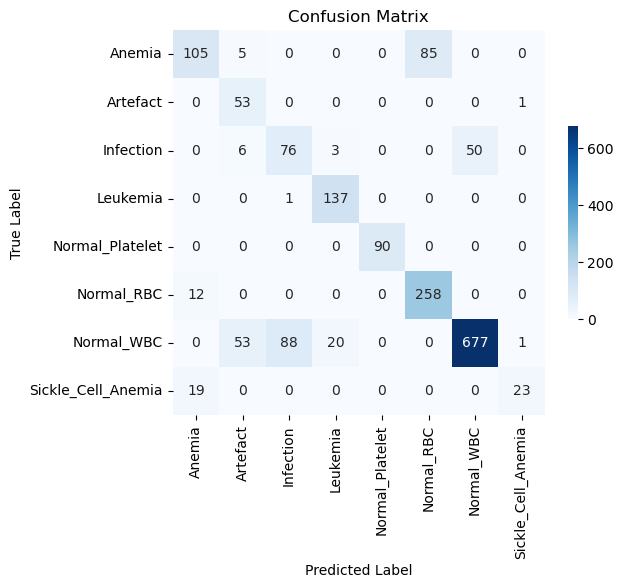

In [45]:
cm = confusion_matrix(y_test, perceptron_search.predict(X_test))
plot_confusion_matrix(cm, perceptron_search.classes_)

Dalla matrice di confusione si nota che il modello fatica a distinguere fra le classi Anemia, Normal_RBC e Sickle_cell_anemia. Questo è comprensibile in quanto sono tutte condizioni di malattia legate ai globuli rossi (Normal_RBC). 

Analogalmente si nota una difficoltà nella classificazione di Infection e Normal_WBC, in particolare il modello è poco preciso nel classificare le cellule di classe infezione come tali. Ciò può essere legato a motivazioni analoghe a Normal_RBC e alla mancanza di bilanciamento delle classi

Di seguito le feature evidenziate come più importanti dall'apprendimento

<Axes: >

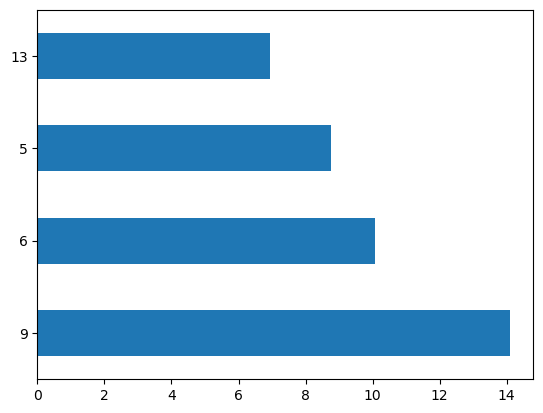

In [46]:
np.abs(coeff).nlargest(4).plot(kind='barh')

Si fa un secondo tentativo con l'espansione polinomiale

In [47]:
poly_perceptron = Pipeline([
    ('std', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('perceptron', Perceptron(n_jobs=-2, early_stopping=True,class_weight='balanced'))
])

parameters = {
    'std': [None, StandardScaler()],
    'perceptron__penalty': [None, 'l1', 'l2', 'elasticnet'],
    'perceptron__alpha': [0.0001, 0.001, 0.01, 1],
    'perceptron__tol': [1e-9, 1e-6, 1e-3, 1, 1e3, 1e6],
}

poly_perceptron_search = GridSearchCV(poly_perceptron, parameters, n_jobs=-2, scoring='f1_weighted')

In [48]:
poly_perceptron_search.fit(X_train,y_train)

,estimator,Pipeline(step... n_jobs=-2))])
,param_grid,"{'perceptron__alpha': [0.0001, 0.001, ...], 'perceptron__penalty': [None, 'l1', ...], 'perceptron__tol': [1e-09, 1e-06, ...], 'std': [None, StandardScaler()]}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [49]:
dump_statistics(poly_perceptron_search,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       0.84      0.81      0.82       455
          Artefact       0.99      0.98      0.98       126
         Infection       0.97      0.95      0.96       315
          Leukemia       0.99      1.00      0.99       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       0.88      0.89      0.89       630
        Normal_WBC       0.99      1.00      0.99      1957
Sickle_Cell_Anemia       0.94      1.00      0.97        98

          accuracy                           0.96      4112
         macro avg       0.95      0.95      0.95      4112
      weighted avg       0.95      0.96      0.95      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.72      0.61      0.66       195
          Artefact       0.96      0.89      0.92        54
         Infection       

In [50]:
print(poly_perceptron_search.best_params_)

{'perceptron__alpha': 0.0001, 'perceptron__penalty': None, 'perceptron__tol': 1e-09, 'std': StandardScaler()}


In [51]:
perceptron_search.best_params_

{'perceptron__alpha': 0.001,
 'perceptron__penalty': 'l1',
 'perceptron__tol': 1,
 'std': StandardScaler()}

Si nota che l'espansione polinomiale ha portato a risultati migliori, guardando in particolare gli f1-score. Usare feature polinomiali che introducano non linearità sembra quindi essere utile per modellare al meglio il dataset.

È stato eseguito un altro tentativo provando ad allenare un perceptron semplice rimuovendo le variabili azzerate dalla L1 e ottenuto un f1-weighted score di 0.7981 che è quindi peggiore. Alterare lo spazio delle feature ha portato quindi a peggiori performance. Era stato eseguito anche un altro esperimento aumentando a 3 il grado del polinomio di `poly_perceptron` portando a risultati migliori, si riconferma quindi che l'espansione polinomiale aiuta a modellare meglio la separazione fra classi

### Logistic Regression

Il modello permette di ottenere un piano di separazione lineare tra le classi

Le scelte principali effettuate sono state:

- standardizzazione dei dati tramite StandardScaler;
- utilizzo della Logistic Regression come classificatore lineare;
- scelta del solver saga;
- impostazione di un numero massimo di iterazioni pari a 5000;
- fissazione del random_state per garantire la riproducibilità dei risultati.

Mentre la ricerca ha considerato:

- metodo di penalizzazione/regolarizzazione;
- valore di C, inverso dell’intensità di regolarizzazione;
- valore di tolleranza tol per il criterio di arresto.

In [52]:
std_lr = Pipeline([
    ('std', StandardScaler()),
    ('lr', LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])

parameters = {
    'lr__penalty': ['l1', 'l2'],
    'lr__C': [0.1, 3, 10, 50, 100],
    'lr__tol': [1e-2,1e-3, 1e-2]
}

lr_search = GridSearchCV(std_lr, parameters, cv=5, n_jobs=-2, return_train_score=True, scoring='f1_weighted')

In [53]:
lr_search.fit(X_train, y_train)

,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'lr__C': [0.1, 3, ...], 'lr__penalty': ['l1', 'l2'], 'lr__tol': [0.01, 0.001, ...]}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [54]:
print('Best parameters:', lr_search.best_params_)

Best parameters: {'lr__C': 3, 'lr__penalty': 'l1', 'lr__tol': 0.001}


In [55]:
lr_coeff = pd.Series(lr_search.best_estimator_[1].coef_[0], index=X_train.columns)

Di seguito le features considerate le più importanti dall'apprendimento:

<Axes: >

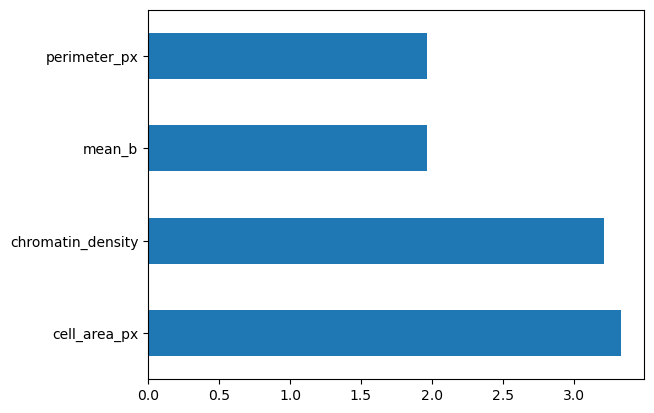

In [56]:
np.abs(lr_coeff).nlargest(4).plot(kind='barh')

E' calcolata l'accuratezza e lo score del modello.

In [57]:
dump_statistics(lr_search,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       0.89      0.68      0.77       455
          Artefact       1.00      1.00      1.00       126
         Infection       0.81      0.63      0.71       315
          Leukemia       1.00      1.00      1.00       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       0.81      0.94      0.87       630
        Normal_WBC       0.94      0.98      0.96      1957
Sickle_Cell_Anemia       0.97      0.97      0.97        98

          accuracy                           0.92      4112
         macro avg       0.93      0.90      0.91      4112
      weighted avg       0.92      0.92      0.91      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.84      0.63      0.72       195
          Artefact       0.98      0.96      0.97        54
         Infection       

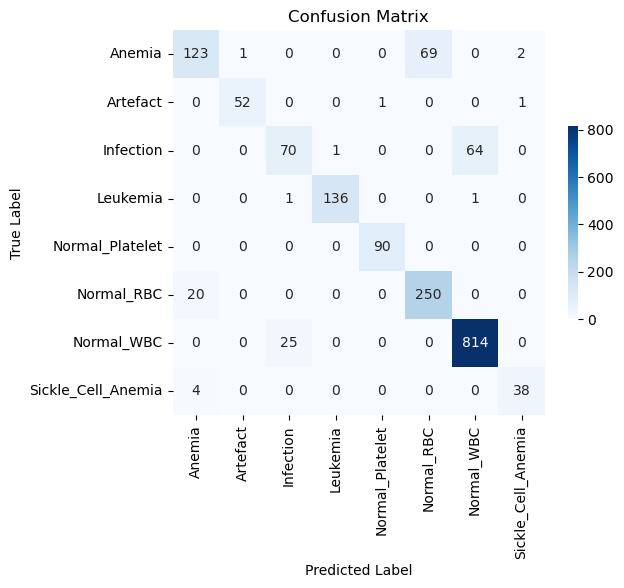

In [58]:
lr_cm = confusion_matrix(y_test, lr_search.predict(X_test))
plot_confusion_matrix(lr_cm, lr_search.classes_)

Dalla matrice di confusione si nota che il modello ha difficoltà a classificare cellule di tipo _infection_ piuttosto che _normal_WBC_ e viceversa, così come _anemia_ e _normal_RBC_ ma si ha una maggiore accuratezza rispetto ai modelli precedenti.

Eseguire un'espansione polinomiale si è rivelato utile per il perceptron. Si è provato a svolgere lo stesso tentativo ma usare un'espansione polinomiale con la regressione logistica era troppo complesso in termine di costo computazionale. Si è pensato quindi di usare Nystroem per fornire un'approssimazione di funzioni kernel e quindi portare le variabili in uno spazio a maggiore dimensionalità senza calcolare le nuove variabili

In [59]:
from sklearn.kernel_approximation import Nystroem

kernel_lr = Pipeline([
    ('std', StandardScaler()),
    ('kernel', Nystroem(random_state=42)),
    ('kernel_std', StandardScaler()),
    ('lr', LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=42
    ))
])

parameters = {
    'kernel__kernel': ['rbf', 'poly', 'sigmoid'],
    # n_components is the number of features to construct (higher = better approximation but slower)
    'kernel__n_components': [50, 100, 200],
    'lr__penalty': ['l1', 'l2'],
    'lr__C': [0.1, 3, 10],
    'lr__tol': [1e-3, 1e-2]
}

kernel_lr_search = GridSearchCV(kernel_lr, parameters, cv=5, n_jobs=-2, return_train_score=True, scoring='f1_weighted')

In [60]:
kernel_lr_search.fit(X_train, y_train)

,estimator,Pipeline(step...ver='saga'))])
,param_grid,"{'kernel__kernel': ['rbf', 'poly', ...], 'kernel__n_components': [50, 100, ...], 'lr__C': [0.1, 3, ...], 'lr__penalty': ['l1', 'l2'], ...}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [61]:
print('Best parameters:', kernel_lr_search.best_params_)

Best parameters: {'kernel__kernel': 'rbf', 'kernel__n_components': 200, 'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__tol': 0.001}


In [62]:
dump_statistics(kernel_lr_search,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       0.93      0.69      0.79       455
          Artefact       1.00      0.99      1.00       126
         Infection       0.93      0.67      0.78       315
          Leukemia       0.99      1.00      0.99       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       0.81      0.97      0.89       630
        Normal_WBC       0.95      0.99      0.97      1957
Sickle_Cell_Anemia       0.99      0.91      0.95        98

          accuracy                           0.93      4112
         macro avg       0.95      0.90      0.92      4112
      weighted avg       0.93      0.93      0.93      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.83      0.63      0.72       195
          Artefact       1.00      0.94      0.97        54
         Infection       

In questo caso si nota un minimo miglioramento. Si ricorda che in questo caso si stanno usando approssimazioni di funzioni kernel e che questo porta intrisecamente ad imprecisione. Inoltre algoritmi come SVM, proprio per natura progettuale, funzionano meglio con le funzioni kernel. Infatti, con SVM si ha la possibilità di usare direttamente il kernel trick perchè la dimensione della matrice del kernel è molto più contenuta rispetto a logistic regression. Permettendo quindi di portare le feature in uno spazio ad alta dimensionalità senza errori di approssimazione

### SVM

In [63]:
std_svm = Pipeline([
    ('std', StandardScaler()),
    ('svm', SVC())
])

parameters = {
    'svm__kernel': ['rbf', 'linear', 'poly'],
    'svm__C': [0.01, 0.1, 1, 10, 50, 100],
}

svm_search = GridSearchCV(std_svm, parameters, cv=3, n_jobs=-2, return_train_score=True, scoring='f1_weighted')

In [64]:
svm_search.fit(X_train, y_train)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.01, 0.1, ...], 'svm__kernel': ['rbf', 'linear', ...]}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [65]:
print('Best parameters:', svm_search.best_params_)  

Best parameters: {'svm__C': 10, 'svm__kernel': 'rbf'}


In [66]:
svm_coeff = pd.Series(svm_search.best_estimator_[1].support_vectors_[0], index=X_train.columns)

Di seguito si evidenziano le features più rilevanti per il modello

<Axes: >

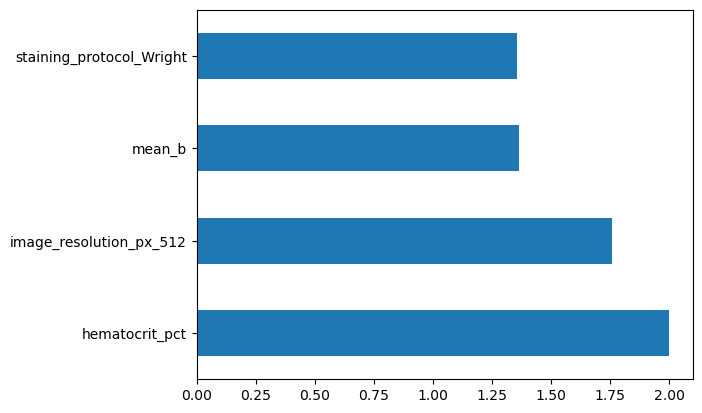

In [67]:
np.abs(svm_coeff).nlargest(4).plot(kind='barh')

In [68]:
dump_statistics(svm_search,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       1.00      0.96      0.98       455
          Artefact       1.00      1.00      1.00       126
         Infection       1.00      1.00      1.00       315
          Leukemia       1.00      1.00      1.00       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       0.98      1.00      0.99       630
        Normal_WBC       1.00      1.00      1.00      1957
Sickle_Cell_Anemia       1.00      1.00      1.00        98

          accuracy                           1.00      4112
         macro avg       1.00      1.00      1.00      4112
      weighted avg       1.00      1.00      1.00      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.85      0.70      0.77       195
          Artefact       1.00      0.94      0.97        54
         Infection       

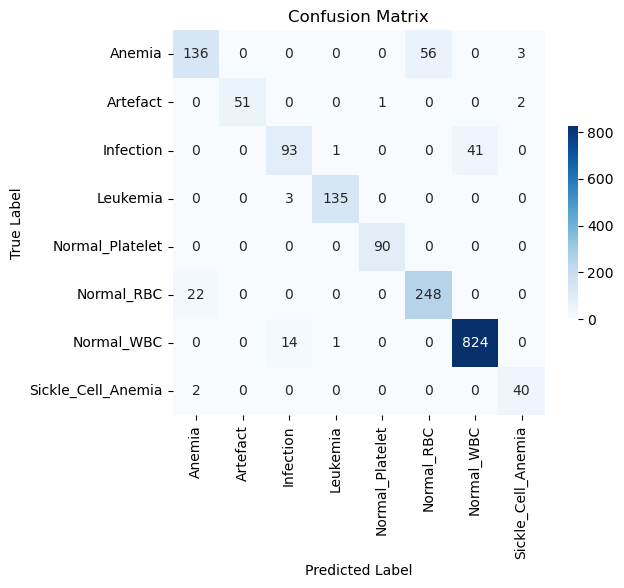

In [69]:
svm_cm = confusion_matrix(y_test, svm_search.predict(X_test))
plot_confusion_matrix(svm_cm, svm_search.classes_)

Dalla matrice si evidenzia, come per gli altri modelli, la difficoltà nel distinguere le cellule di categoria _infection_ e _anemia_ ma si nota una maggiore precisione nella classificazione di queste.

Il dataset presenta molti casi di collinearità che spesso portano ad
un impoverimento delle performance specialmente in modelli lineari.
Si fa un tenativo per rimuovere le feature con forte collinearità e
vedere se l'accuratezza migliora

In [70]:
X_train_no_corr = X_train.drop(columns=['cytoplasm_ratio','circularity','cell_area_px','perimeter_px'])
X_test_no_corr = X_test.drop(columns=['cytoplasm_ratio','circularity','cell_area_px','perimeter_px'])

In [71]:
svm_search_no_corr = GridSearchCV(std_svm, parameters, cv=3, n_jobs=-2, return_train_score=True, scoring='f1_weighted')

In [72]:
svm_search_no_corr.fit(X_train_no_corr,y_train)

,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'svm__C': [0.01, 0.1, ...], 'svm__kernel': ['rbf', 'linear', ...]}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [73]:
dump_statistics(svm_search_no_corr,X_train_no_corr,X_test_no_corr,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       0.91      0.53      0.67       455
          Artefact       1.00      0.98      0.99       126
         Infection       0.87      0.44      0.58       315
          Leukemia       0.99      0.98      0.99       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       0.76      1.00      0.87       630
        Normal_WBC       0.91      0.99      0.95      1957
Sickle_Cell_Anemia       0.80      0.77      0.78        98

          accuracy                           0.89      4112
         macro avg       0.91      0.84      0.85      4112
      weighted avg       0.90      0.89      0.88      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.93      0.45      0.60       195
          Artefact       1.00      0.96      0.98        54
         Infection       

L'accuratezza è peggiorata, questo signica che le variabili eliminate, seppur presentano correlazione. Contengono informazioni importanti per l'apprendimento della separazione tra classi

### Classification Tree

In [74]:
from sklearn.tree import DecisionTreeClassifier

std_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('tree',DecisionTreeClassifier(random_state=42))  
])
parameters = {
    "tree__max_depth": range(4, 10),
    "tree__min_samples_split": [.05, .1, .15],
}
gs_tree = GridSearchCV(std_tree, parameters, cv=3, n_jobs = -2, return_train_score= True, scoring='f1_weighted')
gs_tree.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'tree__max_depth': range(4, 10), 'tree__min_samples_split': [0.05, 0.1, ...]}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [75]:
dump_statistics(gs_tree,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       0.80      0.80      0.80       455
          Artefact       0.89      0.69      0.78       126
         Infection       0.83      0.77      0.80       315
          Leukemia       0.94      0.93      0.94       321
   Normal_Platelet       1.00      0.99      1.00       210
        Normal_RBC       0.90      0.94      0.92       630
        Normal_WBC       0.95      0.96      0.96      1957
Sickle_Cell_Anemia       0.71      0.87      0.78        98

          accuracy                           0.91      4112
         macro avg       0.88      0.87      0.87      4112
      weighted avg       0.91      0.91      0.91      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.80      0.72      0.76       195
          Artefact       0.89      0.78      0.83        54
         Infection       

Il singolo albero di classificazione prodotto produce già dei risultati estremamente promettenti guardando il punteggio. Questo ci suggerisce che una strategia basata sull'utilizzo di alberi potrebbe portare a buoni risultati. Gli alberi, per costruzione, si comportano meglio in presenza di feature ad elevata collinearità, come nel nostro caso. 

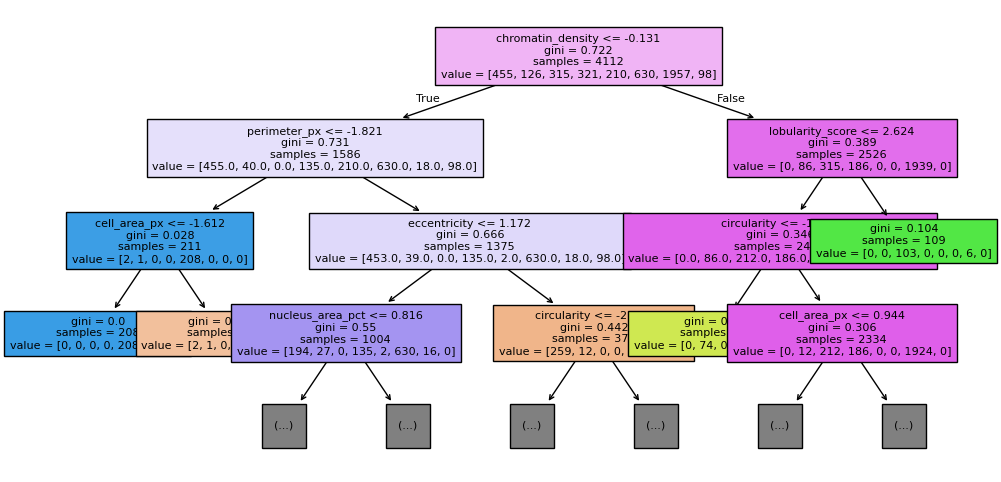

In [76]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 6))
plot_tree(gs_tree.best_estimator_[1],feature_names=X_train.columns, max_depth=3, filled=True, fontsize=8);

### Random Forest

Si procede ad allenare un modello random forest, aspettandosi migliori performance rispetto al semplice classification tree

In [77]:
import math
std_forest = Pipeline([
    ("scaler", StandardScaler()),
    ("forest", RandomForestClassifier(n_jobs=-1, random_state=42))
])


parameters = {
        "scaler": [None, StandardScaler()],
        "forest__n_estimators": [100, 200, 500],
        "forest__max_depth": [None, 5, 10, 20],
        "forest__min_samples_split": [2, 5, 10],
        "forest__max_features": ["sqrt", "log2", None],
        "forest__min_samples_leaf": [1, 2, 5]
}
forest_search = GridSearchCV(std_forest, parameters, cv=3, n_jobs=-2, return_train_score= True, scoring='f1_weighted')#balanced_accuracy

In [78]:
forest_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'forest__max_depth': [None, 5, ...], 'forest__max_features': ['sqrt', 'log2', ...], 'forest__min_samples_leaf': [1, 2, ...], 'forest__min_samples_split': [2, 5, ...], ...}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [79]:
print('Best parameters:', forest_search.best_params_)  

Best parameters: {'forest__max_depth': None, 'forest__max_features': None, 'forest__min_samples_leaf': 1, 'forest__min_samples_split': 2, 'forest__n_estimators': 200, 'scaler': StandardScaler()}


In [80]:
dump_statistics(forest_search,X_train,X_test,y_train,y_test)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       1.00      1.00      1.00       455
          Artefact       1.00      1.00      1.00       126
         Infection       1.00      1.00      1.00       315
          Leukemia       1.00      1.00      1.00       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       1.00      1.00      1.00       630
        Normal_WBC       1.00      1.00      1.00      1957
Sickle_Cell_Anemia       1.00      1.00      1.00        98

          accuracy                           1.00      4112
         macro avg       1.00      1.00      1.00      4112
      weighted avg       1.00      1.00      1.00      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.93      0.85      0.89       195
          Artefact       1.00      0.94      0.97        54
         Infection       

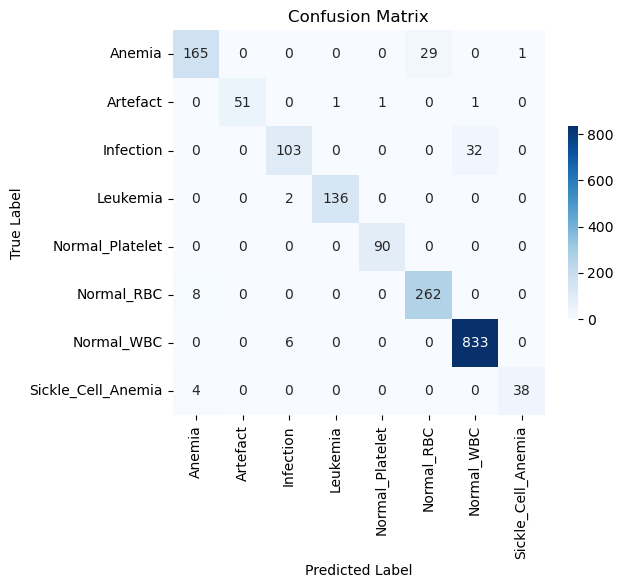

In [81]:
forest_cm = confusion_matrix(y_test, forest_search.predict(X_test))
plot_confusion_matrix(forest_cm, forest_search.classes_)

Guardando principalmente gli F1-score si nota un notevole miglioramento rispetto al semplice albero di classificazione. Purtroppo si evidenzia ancora lo stesso problema per cui per i modelli è difficile apprendere la differenza fra _Anemia_ e _Normal_RBC_ e fra _Infection_ e _Normal_WBC_ che porta ad ottenere nello specifico punteggi di recall più bassi per queste classi

Rappresentiamo il primo dei 200 alberi generati

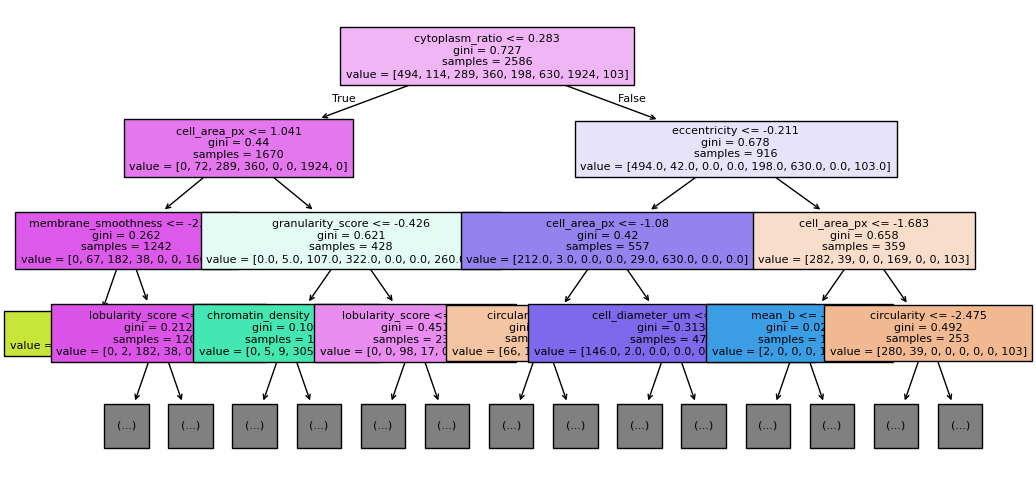

In [82]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 6))
plot_tree(forest_search.best_estimator_[1].estimators_[0],feature_names=X_train.columns, max_depth=3, filled=True, fontsize=8);

### XGBoost

In [83]:
!pip install xgboost

In [84]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

Il modello XGBoost richiede che la variabile target y sia rappresentata da classi numeriche:

In [171]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [172]:
std_xgb = Pipeline([
    ('std', StandardScaler()),
    ('xgb', XGBClassifier(n_jobs=8, objective="multi:softprob"))
])

parameters = {
    'xgb__eta': [0.01, 0.05, 0.1],
    'xgb__min_child_weight': [4, 10],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__n_estimators': [150, 300, 500],
    'xgb__alpha': [0.0001, 0.001, 0.01]
}

xgb_search = GridSearchCV(std_xgb, parameters, cv=3, n_jobs=-2, return_train_score=True, scoring='f1_weighted')

In [173]:
xgb_search.fit(X_train, y_train_enc)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgb__alpha': [0.0001, 0.001, ...], 'xgb__eta': [0.01, 0.05, ...], 'xgb__max_depth': [3, 4, ...], 'xgb__min_child_weight': [4, 10], ...}"
,scoring,'f1_weighted'
,n_jobs,-2
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [174]:
print('Best parameters:', xgb_search.best_params_)  

Best parameters: {'xgb__alpha': 0.0001, 'xgb__eta': 0.1, 'xgb__max_depth': 4, 'xgb__min_child_weight': 4, 'xgb__n_estimators': 500}


Si evidenziano le features più importanti per il modello:

In [89]:
xgb_coeff = pd.Series(xgb_search.best_estimator_[1].feature_importances_, index=X_train.columns)

<Axes: >

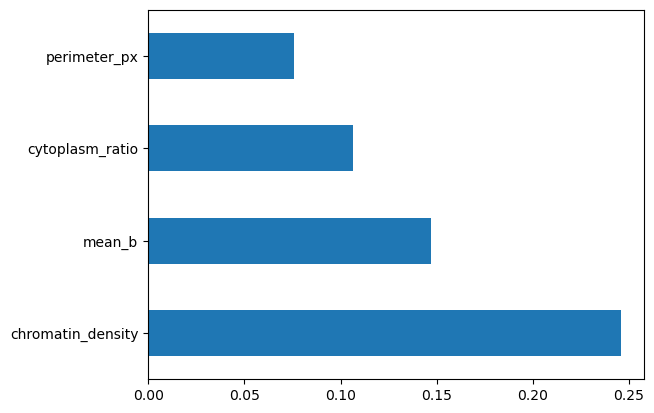

In [90]:
np.abs(xgb_coeff).nlargest(4).plot(kind='barh')

In [175]:
dump_statistics(xgb_search,X_train,X_test,y_train_enc,y_test_enc,le)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       1.00      1.00      1.00       455
          Artefact       1.00      1.00      1.00       126
         Infection       1.00      1.00      1.00       315
          Leukemia       1.00      1.00      1.00       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       1.00      1.00      1.00       630
        Normal_WBC       1.00      1.00      1.00      1957
Sickle_Cell_Anemia       1.00      1.00      1.00        98

          accuracy                           1.00      4112
         macro avg       1.00      1.00      1.00      4112
      weighted avg       1.00      1.00      1.00      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.98      0.89      0.93       195
          Artefact       1.00      0.96      0.98        54
         Infection       

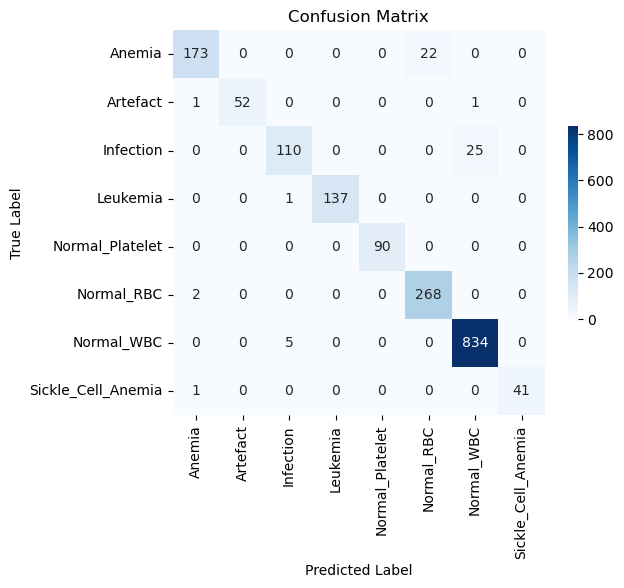

In [176]:
xgb_cm = confusion_matrix(y_test_enc, xgb_search.predict(X_test))
plot_confusion_matrix(xgb_cm, xgb_search.classes_, le)

Il modello XGBoost ha ottenuto risultati molto positivi, sia per i valori di precisione e di recall nelle varie classi e di conseguenza i punteggi f1 sono prossimi a 1.0. Sono presenti casi in cui la predizione risulta errata, ma sono meno frequenti rispetto agli altri modelli confrontati. 
Si nota ancora un problema di recall nelle classi di _anemia_ e _infection_.

# Parte 5 - Model comparison

In [93]:
from sklearn.metrics import mean_squared_error
from scipy.special import softmax
from scipy import stats

In [94]:
def mse_model(model):
    y_one_hot = pd.get_dummies(y_test, columns="disease_category", dtype=int)
    try:
        preds = model.predict_proba(X_test)
    except  AttributeError:
            scores = model.decision_function(X_test)
            preds = softmax(scores, axis=1)
        
    model_mse = mean_squared_error(y_one_hot, preds)
    return model_mse

In [95]:
def model_comparison(mse_1, mse_2, confidence = 0.95):
    alfa = 1 - confidence
    z_half_alfa = stats.norm.ppf(1-alfa/2)
    d = np.abs(mse_1 - mse_2)
    variance = (mse_1 * (1 - mse_1)) / len(X_test) + (mse_2 * (1 - mse_2)) / len(X_test)
    d_min = d - z_half_alfa * np.sqrt(variance)
    d_max = d + z_half_alfa * np.sqrt(variance)
    
    return (d_min, d_max)

### Riepilogo F1 Score

In [96]:
models = [
    perceptron_search,
    poly_perceptron_search,
    svm_search,
    lr_search,
    gs_tree,
    forest_search,
    xgb_search
]

for model in models:
    nome_modello = model.best_estimator_[-1].__class__.__name__
    miglior_f1 = model.best_score_
    print(f"{nome_modello}:\n\t\t\t\t{miglior_f1:.4f}")

Perceptron:
				0.8397
Perceptron:
				0.8801
SVC:
				0.9006
LogisticRegression:
				0.8924
DecisionTreeClassifier:
				0.8858
RandomForestClassifier:
				0.9596
XGBClassifier:
				0.9670


Si notano i migliori score di f1

### SVM vs Perceptron

In [97]:
print('Interval {}'.format(np.round(model_comparison(mse_model(svm_search), mse_model(perceptron_search)), 4)))

Interval [0.0019 0.0272]


### Logistic Regression vs Perceptron

In [98]:
print('Interval {}'.format(np.round(model_comparison(mse_model(lr_search), mse_model(perceptron_search)), 4)))

Interval [0.0146 0.038 ]


### SVM vs Logistic regression

In [99]:
print('Interval {}'.format(np.round(model_comparison(mse_model(svm_search), mse_model(lr_search)), 4)))

Interval [0.0014 0.0221]


### Random Forest vs Classification Tree

In [100]:
print('Interval {}'.format(np.round(model_comparison(mse_model(forest_search), mse_model(gs_tree)), 4)))

Interval [0.003  0.0191]


### XGBoost vs Classification Tree

In [101]:
print('Interval {}'.format(np.round(model_comparison(mse_model(xgb_search), mse_model(gs_tree)), 4)))

Interval [0.0065 0.0218]


### XGBoost vs Random Forest

In [102]:
print('Interval {}'.format(np.round(model_comparison(mse_model(xgb_search), mse_model(forest_search)), 4)))

Interval [-0.0028  0.009 ]


### SVM vs Random Forest

In [103]:
print('Interval {}'.format(np.round(model_comparison(mse_model(svm_search), mse_model(forest_search)), 4)))

Interval [0.0121 0.0307]


### XGBoost vs SVM

In [104]:
print('Interval {}'.format(np.round(model_comparison(mse_model(xgb_search), mse_model(svm_search)), 4)))

Interval [0.0156 0.0335]


## Bilanciamento delle classi

Si prova a fare un tentativo di bilanciamento delle classi per vedere se questo migliora le performance del modello XGBoost.
Usiamo SMOTE per generare dati sintetici su cui allenare il modello

In [178]:
xgb_standard_mse = mse_model(xgb_search)

In [105]:
from imblearn.over_sampling import SMOTE

In [106]:
balancer = SMOTE(random_state=42)
X_res,y_res = balancer.fit_resample(X_train,y_train)

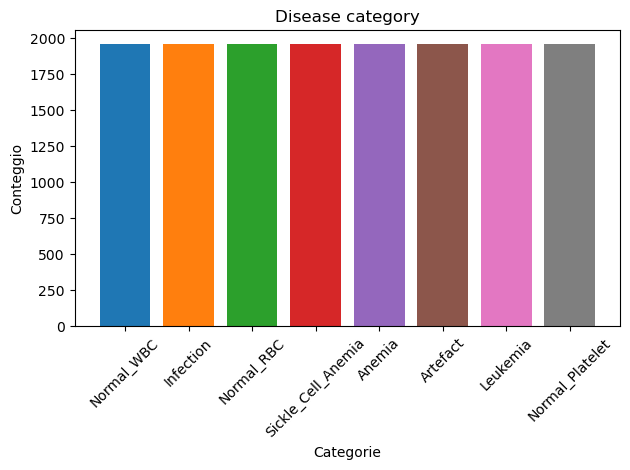

In [107]:
X_res["disease_category"] = y_res
counts = X_res['disease_category'].value_counts()
num_categorie = len(counts)

colori = plt.cm.tab10(range(num_categorie)) 

plt.bar(counts.index, counts.values, color=colori)
plt.title('Disease category')
plt.xlabel('Categorie')
plt.ylabel('Conteggio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X_res.drop(columns=['disease_category'], inplace=True)

In [126]:
from sklearn.base import clone
y_train_res_enc = le.transform(y_res)
xgb_model_balanced_class = clone(xgb_search.best_estimator_) 
xgb_model_balanced_class.fit(X_res,y_train_res_enc)

,steps,"[('std', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


In [127]:
dump_statistics(xgb_model_balanced_class,X_res,X_test,y_train_res_enc,y_test_enc)

Classification report on train set 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1957
           1       1.00      1.00      1.00      1957
           2       1.00      1.00      1.00      1957
           3       1.00      1.00      1.00      1957
           4       1.00      1.00      1.00      1957
           5       1.00      1.00      1.00      1957
           6       1.00      1.00      1.00      1957
           7       1.00      1.00      1.00      1957

    accuracy                           1.00     15656
   macro avg       1.00      1.00      1.00     15656
weighted avg       1.00      1.00      1.00     15656

Classification report on test set 
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       195
           1       1.00      0.94      0.97        54
           2       0.91      0.84      0.88       135
           3       0.99      0.99      0.99       138
       

In [179]:
print('Interval {}'.format(np.round(model_comparison(xgb_standard_mse, mse_model(xgb_model_balanced_class)), 4)))

Interval [-0.0044  0.0068]


Notiamo rispetto al modello principale un lieve peggioramento generale. In particolare il modello è meno preciso quindi, aumentano i casi di falsi positivi. Questo risultato può essere dovuto a una situazione di overfitting, infatti si nota un'estrema precisione nel training set. L'introduzione di un elevato numero di campioni sintetici, specialmente per classi poco rappresentate, può aver portato il modello a peggiorare la sua capacità di generalizzazione e ad appredere informazioni che non corrispondono totalmente con la realtà.

Ad ogni modo notiamo che l'intervallo di confidenza contiene il valore 0, ergo si deduce che la differenza di errore fra i due modelli non è statisticamente significativa

## Aggiunta nuove feature

In [180]:
X_train["mentzer_index"] = X_train.mcv_fl / X_train.rbc_count_millions_per_ul
X_train["mentzer_index"]

757     16.812500
856     18.634615
5869    15.319149
133     16.365385
3185    19.119850
          ...    
2312    16.557692
2296    17.137255
4099    18.076923
3075    19.071429
3099    14.971209
Name: mentzer_index, Length: 4112, dtype: float64

In [181]:
X_test["mentzer_index"] = X_test.mcv_fl / X_test.rbc_count_millions_per_ul

In [130]:
xgb_model_new_feature = clone(xgb_search.best_estimator_)
xgb_model_new_feature.fit(X_train,y_train_enc)

,steps,"[('std', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None


In [182]:
dump_statistics(xgb_model_new_feature,X_train,X_test,y_train_enc,y_test_enc)

Classification report on train set 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       455
           1       1.00      1.00      1.00       126
           2       1.00      1.00      1.00       315
           3       1.00      1.00      1.00       321
           4       1.00      1.00      1.00       210
           5       1.00      1.00      1.00       630
           6       1.00      1.00      1.00      1957
           7       1.00      1.00      1.00        98

    accuracy                           1.00      4112
   macro avg       1.00      1.00      1.00      4112
weighted avg       1.00      1.00      1.00      4112

Classification report on test set 
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       195
           1       1.00      0.96      0.98        54
           2       0.96      0.81      0.88       135
           3       1.00      0.99      1.00       138
       

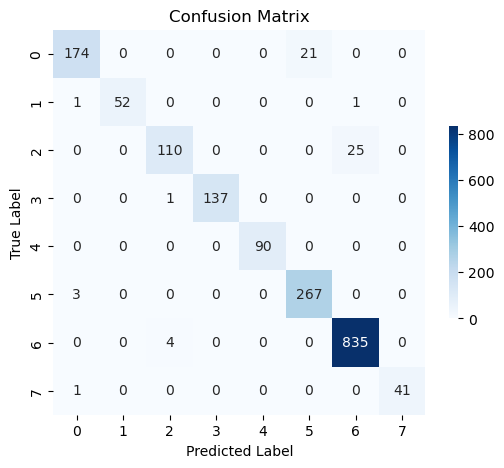

In [183]:
xgb_cm = confusion_matrix(y_test_enc, xgb_model_new_feature.predict(X_test))
plot_confusion_matrix(xgb_cm, xgb_search.classes_)

In [184]:
print('Interval {}'.format(np.round(model_comparison(xgb_standard_mse, mse_model(xgb_model_new_feature)), 4)))

Interval [-0.0052  0.0054]


Notiamo anche in questo caso che l'intervallo di confidenza contiene il valore 0, la differenza di errore che si rileva è quindi frutto di questo specifico test set e si potrebbero avere risultati diversi con dati diversi. Si deduce che il cambiamento non ha introdotto alcun miglioramento o peggioramento che abbia valenza statistica

## XGBoost nested cross

In [115]:
from sklearn.model_selection import KFold, cross_val_score
external_cv = KFold(n_splits=4, shuffle=True, random_state=42)

xgb_cross = cross_val_score(
    estimator=xgb_search, 
    X=X_train,
    y=y_train_enc, 
    cv=external_cv, 
    n_jobs=1,
    scoring='f1_weighted', 
)

In [116]:
print('Best parameters:', xgb_search.best_params_)  

Best parameters: {'xgb__alpha': 0.0001, 'xgb__eta': 0.1, 'xgb__max_depth': 4, 'xgb__min_child_weight': 4, 'xgb__n_estimators': 500}


In [117]:
dump_statistics(xgb_search,X_train,X_test,y_train_enc,y_test_enc,le)

Classification report on train set 
                    precision    recall  f1-score   support

            Anemia       1.00      1.00      1.00       455
          Artefact       1.00      1.00      1.00       126
         Infection       1.00      1.00      1.00       315
          Leukemia       1.00      1.00      1.00       321
   Normal_Platelet       1.00      1.00      1.00       210
        Normal_RBC       1.00      1.00      1.00       630
        Normal_WBC       1.00      1.00      1.00      1957
Sickle_Cell_Anemia       1.00      1.00      1.00        98

          accuracy                           1.00      4112
         macro avg       1.00      1.00      1.00      4112
      weighted avg       1.00      1.00      1.00      4112

Classification report on test set 
                    precision    recall  f1-score   support

            Anemia       0.97      0.89      0.93       195
          Artefact       1.00      0.96      0.98        54
         Infection       